In [1]:
import gc
import numpy as np
import os
import re
import sys

import pandas as pd
import tensorflow_data_validation as tfdv

#VERSION = "20221025"
DATA_DIR = r"Z:\13.Data Science\Projects\2022_GI_Xsell\Data"
PROJECT_DIR = "../"
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
META_DATA_DIR = os.path.join(DATA_DIR, "meta_and_reference_data")
VER_1025_DIR = os.path.join(RAW_DATA_DIR, "20221025")
VER_1118_DIR = os.path.join(RAW_DATA_DIR, "20221118")
VER_1122_DIR = os.path.join(RAW_DATA_DIR, "20221122")
VER_1212_DIR = os.path.join(RAW_DATA_DIR, "20221212")
GI_DATA_DIR = os.path.join(RAW_DATA_DIR, "GI")
PA_DATA_DIR = os.path.join(GI_DATA_DIR, "Travel", "202210")
sys.path.insert(0, DATA_DIR)
sys.path.insert(0, PROJECT_DIR)

from datetime import datetime
from dateutil.relativedelta import relativedelta

# from src.utils.common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST, TRAVEL_SINGLE_MULTI_TRIP_DICT
# from src.utils.helper_function import find_plan_type, one_hot

In [2]:
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
BASESTAT_FILE = os.path.join(PA_DATA_DIR, "basestat.parquet")
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase_df.parquet")
PREMBASE_FILE = os.path.join(PA_DATA_DIR, "prembase.parquet")
CLIENT_DATA_MAPPING_FILE = os.path.join(PROCESSED_DATA_DIR, "processed_client_data.parquet")

In [4]:
prembase_df = pd.read_parquet(PREMBASE_FILE)

# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["CCDATE"] = pd.to_datetime(prembase_df["CCDATE"], format="%Y%m%d")
prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")

## import prembase file


In [5]:
prembase_df = pd.read_parquet(PREMBASE_FILE)


In [6]:
# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["CCDATE"] = pd.to_datetime(prembase_df["CCDATE"], format="%Y%m%d")
# prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")
# strip contrnb 
prembase_df['contrnb'] = prembase_df['contrnb'].str.strip()
# strip COWNNUM
prembase_df['COWNNUM'] = prembase_df['COWNNUM'].str.strip()

In [7]:
prembase_df.sample(10)

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE,CLTSEX,CLTDOB,MARRYD,NATLTY,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp
3455931,96228037,2015-05-01,46.0,1.0,1.0,20150501.0,30.92,9.28,1.63,2015.0,5.0,1.0,20150506.0,T405,STR,2015-05-01,20150504.0,None,2003872,E04430,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,30.47166,9.28,N,STRD0313,TravelSurance (single trip),N,P,F,19680626.0,NaN,HK,ATH,99999999.0,PA,NaN,600000.0,S,S1,1,1.0,N,Single,20150504.0,NaN,0.0,99999999.0,4.0,1.0,Area 1,Self & Spouse,N,NA,3. 4-5 Days,NWBS,HSBC - Dummy,637(SURANCE)-NET,9998,Banca - HSBC,0.0,TravelSurance,-5.0,1. 0 days or les,1. 1 person,4. Age 41 - 50,-0.0,Single,NaN,NaN,NaN,1. Discount = 1% to 10%
4230453,S7016484,2019-11-11,26.0,1.0,1.0,20191111.0,192.00,0.00,0.00,2019.0,11.0,1.0,20191111.0,T405,STC,2019-11-11,20191117.0,None,1533640,04203,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,190.52160,0.00,N,STS1118,SmartTraveller (Single),N,P,F,19930902.0,NaN,None,ATP,99999999.0,PA,IO,500000.0,None,SD,9,1.0,NaN,Single,20191117.0,NaN,0.0,99999999.0,7.0,1.0,Essential,Insured Only,N,N,4. 6-7 Days,NWBS,Travel SWAP,TRAVEL SWAP,GT03,AXA Online Direct,0.0,SmartTraveller,0.0,1. 0 days or les,1. 1 person,2. Age 17 - 30,-0.0,Single,NaN,NaN,NaN,0. No Discount
2340647,25551402,2018-10-15,34.0,1.0,1.0,20181015.0,54.54,16.36,6.06,2018.0,10.0,1.0,20181013.0,T405,STR,2018-10-15,20181025.0,None,2641639,E06067,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,54.10368,16.36,N,BSTR1017,TravelSurance (single trip),N,P,M,19831027.0,NaN,None,ATH,99999999.0,PA,NaN,1000000.0,I,I2,2,1.0,N,Single,20181025.0,NaN,0.0,99999999.0,11.0,1.0,Area 2,Self Only,N,NA,6. 11-14 Days,NWBS,HSBC - Dummy,637(SURANCE)-ATM,9998,Banca - HSBC,0.0,TravelSurance,2.0,2. 1 to 5 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,1. Discount = 1% to 10%
3090710,25950637,2020-01-19,64.0,1.0,3.0,20200119.0,0.00,0.00,0.00,2020.0,4.0,1.0,20200402.0,T409,STZ,2020-01-19,20210118.0,None,2974258,E81403,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,ENDO,0.00000,0.00,N,BSTZ0518,Multi Trip 2018,N,P,M,19550501.0,NaN,None,ATH,99999999.0,PA,NaN,2000000.0,*,*Z,Z,1.0,N,Annual,20210118.0,NaN,0.0,NaN,NaN,1.0,Worldwide,Standard,N,NA,Annual,NWBS,HSBC - Dummy,637(SURANCE)-RDP,9998,Banca - HSBC,0.0,TravelSurance - 2018,4.0,2. 1 to 5 days,1. 1 person,6. Age 61 - 70,-0.0,0,NaN,NaN,NaN,0. No Discount
4256487,Z0131831,2005-02-09,50.0,1.0,1.0,20050209.0,214.50,0.00,0.00,2005.0,1.0,1.0,20050119.0,T405,STS,2005-02-09,20050214.0,None,0076823,02784,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,0.00000,0.00,N,STS0804,SmartTraveller (Annual),N,P,F,19540524.0,M,HK,ATP,99999999.0,PA,D0,2000000.0,None,B2,9,1.0,NaN,Single,20050214.0,NaN,0.0,99999999.0,6.0,1.0,VIP,Insured & Spouse,N,N,4. 6-7 Days,NWBS,Direct - Staff Referral,DIRECT - STAFF REFERRAL,DIRR,AXA Offline Direct,0.0,SmartTraveller,21.0,6. 21 to 25 days,1. 1 person,4. Age 41 - 50,-0.0,Single,NaN,NaN,NaN,0. No Discount
2408919,25584737,2018-12-02,42.0,2.0,1.0,20181202.0,246.33,73.90,27.37,2018.0,12.0,1.0,20181125.0,T405,STR,2018-12-02,20181209.0,None,2654051,E81403,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,244.35936,73.90,N,BSTR1017,TravelSurance (single trip),N,P,F,19760222.0,S,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,I,I2,2,NaN,N,Single,20181209.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self Only,N,NA,5. 8-10 Days,NWBS,HSBC - Dummy,637(SURANCE)-RDP,9998,Banca - HSBC,0.0,TravelSurance,7.0,3. 6 to 10 days,1. 1 person,4. Age 

In [8]:
# get useful columns from prembase_df 
useful_prembase_df=prembase_df[['COWNNUM','contrnb','OCCDATE','CCDATE','channel','product','plan1','plan2','plan3','duration','duration_grp','age','age_gp','gwp','nbrn','CLTSEX']]
# show shape of useful_prembase_df
useful_prembase_df.shape


(4844657, 16)

In [9]:
# count how many unique channel for each contrnb
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False)

contrnb
Z1137353    2
Z0982727    2
Z0065017    2
Z1117919    2
Z0057191    2
           ..
25289859    1
25289860    1
25289861    1
25289862    1
ZS753243    1
Name: channel, Length: 2421762, dtype: int64

In [10]:
# count how many unique contrnb has more than 1 channel
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).value_counts()

1    2421497
2        265
Name: channel, dtype: int64

In [11]:
# count percentage of unique contrnb has more than 1 channel
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).value_counts(normalize=True)

1    0.999891
2    0.000109
Name: channel, dtype: float64

In [12]:
# show some row where contrnb has more than 1 channel
useful_prembase_df[useful_prembase_df['contrnb'].isin(useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).index[useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).values>1])]

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX
3476014,0208443,S5006345,2009-12-18,2009-12-18,Agents & Broker,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,54.0,5. Age 51 - 60,1510.00,NB,M
3476015,0208443,S5006345,2009-12-18,2010-12-18,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,55.0,5. Age 51 - 60,1510.00,RN,M
3476016,0208443,S5006345,2009-12-18,2011-12-18,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,366.0,Annual,56.0,5. Age 51 - 60,1510.00,RN,M
3476017,0208443,S5006345,2009-12-18,2012-12-18,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,57.0,5. Age 51 - 60,1600.00,RN,M
3476018,0208443,S5006345,2009-12-18,2013-12-18,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,58.0,5. Age 51 - 60,1600.00,RN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4818332,1663509,Z1478738,2021-09-20,2021-09-20,LP,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,495.00,NB,M
4818333,1663509,Z1478738,2021-09-20,2021-09-20,LP,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,2025.00,NB,M
4818334,1663509,Z1478738,2021-09-20,2022-09-20,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,1138.50,RN,M
4818335,1663509,Z1478738,2021-09-20,2022-09-20,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,569.25,RN,M


In [13]:
265/(2421497+265)

0.00010942446037224137

# import client data

In [14]:
client_data_df = pd.read_parquet(CLIENT_DATA_MAPPING_FILE)

In [15]:
client_data_df.sample(10)

,CLNTNUM,VALIDFLAG,CLTTYPE,SECUITYNO,CLTSEX,OCCPCODE,CLTDOB,START_DATE,MARRYD,NATLTY,modified_SECUITYNO
4475347,2281408,1,P,Y136606(6),F,None,19900330.0,20160531.0,None,HK,Y136606
3934101,X1464608,1,P,Z894618(4),M,UNKN,19870616.0,20120323.0,S,HK,Z894618
1346903,G8615128,1,P,K795862(5),M,UNKN,19780326.0,99999999.0,S,None,K795862
4813368,2488300,1,P,K306413(1),F,None,19740202.0,20170529.0,None,None,K306413
2434957,O9419503,1,P,R218074(9),M,UNKN,19770813.0,99999999.0,S,None,R218074
2532772,N0842861,1,P,E587769(9),F,OTH,19540809.0,99999999.0,S,None,E587769
1351818,G8666807,1,P,E703451(6),F,OTH,19560807.0,99999999.0,M,None,E703451
3130810,N6978878,1,P,E896029(5),F,UNKN,19640220.0,99999999.0,M,None,E896029
3814916,M4524616,1,P,K429642(7),M,UNKN,19750609.0,99999999.0,None,None,K429642
3857991,M4959869,1,P,Z207141(0),M,UNKN,19800404.0,99999999.0,None,None,Z207141


In [16]:
# strip CLINTNUM SECUITYNO modified_SECUITYNO
client_data_df['CLNTNUM'] = client_data_df['CLNTNUM'].str.strip()
client_data_df['SECUITYNO'] = client_data_df['SECUITYNO'].str.strip()
client_data_df['modified_SECUITYNO'] = client_data_df['modified_SECUITYNO'].str.strip()



In [17]:
useful_client_data_df=client_data_df[['CLNTNUM','modified_SECUITYNO']]

In [18]:
print("prembase_df size before merge:", useful_prembase_df.shape)
#COWNNUM=client number 
# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
useful_prembase_w_client_df = useful_prembase_df.merge(useful_client_data_df, left_on="COWNNUM", right_on='CLNTNUM' ,how="left")

print("prembase_df size after merge:", useful_prembase_w_client_df.shape)

prembase_df size before merge: (4844657, 16)
prembase_df size after merge: (4844657, 18)


In [19]:
useful_prembase_w_client_df.sample(10)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
4622851,1206208,Z1085423,2018-02-28,2019-02-28,LP,SmartTraveller (Annual),Annual,Classic,Insured Only,NaN,Annual,51.0,5. Age 51 - 60,0.00,RN,F,1206208,G260154
1556407,2521596,25101055,2017-08-01,2017-08-01,Banca - HSBC,TravelSurance (single trip),Single,Area 2,Family,0.0,7. 15-30 Days,41.0,4. Age 41 - 50,765.00,NB,M,2521596,K517192
4405126,0942109,Z0751875,2016-02-25,2016-02-25,AXA Online Direct,SmartTraveller (Single),Single,Classic,Insured Only,4.0,3. 4-5 Days,26.0,2. Age 17 - 30,128.00,NB,F,0942109,Y049701
3980114,0894468,S5305296,2016-12-22,2016-12-22,Agents & Broker,SmartTraveller (Single),Single,VIP,Insured Only,8.0,5. 8-10 Days,28.0,2. Age 17 - 30,253.00,NB,M,0894468,Z901266
2215203,2711227,25480343,2018-08-04,2018-08-04,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Family,6.0,4. 6-7 Days,39.0,3. Age 31 - 40,56.03,NB,M,2711227,K959421
1000859,2354333,24826056,2016-09-29,2018-09-29,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,74.0,7. Age 71 - 80,283.80,RN,F,2354333,XD1532273
2758745,2773411,25796116,2019-06-25,2019-06-25,Banca - HSBC,Single Trip 2018,Single,Worldwide,Standard,14.0,6. 11-14 Days,50.0,4. Age 41 - 50,85.16,NB,F,2773411,C598971
4022578,1340986,S5332041,2018-10-31,2018-10-31,Agents & Broker,SmartTraveller (Single),Single,Classic,Insured Only,6.0,4. 6-7 Days,35.0,3. Age 31 - 40,360.00,NB,F,1340986,Z094289
1659421,2551425,25151720,2017-09-30,2017-09-30,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,1. 0 Days,34.0,3. Age 31 - 40,-184.45,NB,F,2551425,R915129
4302614,0424462,Z0351738,2009-03-04,2009-03-04,Agents & Broker,SmartTraveller (Annual),Single,Classic,Insured Only,7.0,4. 6-7 Days,33.0,3. Age 31 - 40,123.00,NB,F,0424462,0424462


In [20]:
# see how many rows where modified_SECUITYNO is NaN, anc value count channel

print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()].shape)

(50933, 18)


In [21]:
# see how many unique clients where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["COWNNUM"].nunique())

32227


In [22]:
# show some rows

In [23]:
# see how many rows where CLNTNUM is NaN, 
print(useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].shape)

(50933, 18)


In [24]:
# show some rows where CLNTNUM is NaN
useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].sample(10)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
4842968,1746284,Z1657089,2022-10-21,2022-10-21,LP,SmartTraveller Plus (Single),Single,Prestige,Insured Only,5.0,3. 4-5 Days,32.0,3. Age 31 - 40,244.00,NB,F,NaN,NaN
3203920,6092144,26002727,2022-09-23,2022-09-23,Banca - HSBC,Single Trip 2018,Single,Worldwide,Standard,16.0,7. 15-30 Days,33.0,3. Age 31 - 40,145.88,NB,M,NaN,NaN
4823512,1717954,Z1480178,2022-09-17,2022-09-17,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,0.0,1. 0 Days,9999.0,9. unknown,2025.00,NB,F,NaN,NaN
4789796,1711398,Z1378870,2022-07-31,2022-07-31,AXA Online Direct,SmartTraveller Plus (Single),Single,Superior,Insured Only,3.0,2. 1-3 Days,45.0,4. Age 41 - 50,244.50,NB,F,NaN,NaN
4838358,1731638,Z1649130,2022-09-27,2022-09-27,JLT (OSC),UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,450.00,NB,F,NaN,NaN
4791817,1715425,Z1380722,2022-07-30,2022-07-30,LP,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,65.0,6. Age 61 - 70,369.00,NB,M,NaN,NaN
4835950,1736975,Z1643699,2022-12-24,2022-12-24,AXA Online Direct,SmartTraveller Plus (Single),Single,Economy,Insured Only,9.0,5. 8-10 Days,32.0,3. Age 31 - 40,464.10,NB,F,NaN,NaN
4836659,1738560,Z1644410,2022-10-16,2022-10-16,LP,SmartTraveller Plus (Annual),Annual,Prestige,Insured Only,365.0,Annual,48.0,4. Age 41 - 50,1840.00,NB,F,NaN,NaN
3198439,6087637,26000107,2022-08-20,2022-08-20,Banca - HSBC,Single Trip 2018,Single,Worldwide,Standard,3.0,2. 1-3 Days,60.0,5. Age 51 - 60,210.25,NB,F,NaN,NaN
3216951,6098189,26009171,2022-10-28,2022-10-28,Banca - HSBC,Single Trip 2018,Single,Asia,Standard,10.0,5. 8-10 Days,61.0,6. Age 61 - 70,586.16,NB,M,NaN,NaN


In [25]:
# number of unique COWNNUM in useful_prembase_w_client_df
print(useful_prembase_w_client_df['COWNNUM'].nunique())

1499865


In [26]:
PERCENTAGE_OF_ROWS_WITHOUT_ID=(50933/1499865)*100
PERCENTAGE_OF_ROWS_WITHOUT_ID

3.395838958839629

In [27]:
# see how many unique COWNNUM where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()]["COWNNUM"].nunique())

32227


In [28]:
# show some unique COWNNUM where CLNTNUM is NaN
useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()]

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
1205949,6098322,24926283,2016-05-10,2022-05-10,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,71.0,7. Age 71 - 80,0.0,RN,F,NaN,NaN
1205950,6098322,24926283,2016-05-10,2022-05-10,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,71.0,7. Age 71 - 80,0.0,RN,F,NaN,NaN
1379818,6088691,25013794,2017-04-24,2022-04-24,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,46.0,4. Age 41 - 50,0.0,RN,NaN,NaN,NaN
1379819,6088691,25013794,2017-04-24,2022-04-24,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,46.0,4. Age 41 - 50,0.0,RN,NaN,NaN,NaN
2742349,6088891,25750454,2022-09-13,2022-09-13,Banca - HSBC,BUSINESS TRAVELCARE,NaN,Area 2,1 Person,365.0,10. >180 Days,9999.0,9. unknown,530.4,NB,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4844641,1747630,Z1937478,2022-10-17,2022-10-17,Agents & Broker,SmartTraveller Plus (Single),Single,Basic,Insured Only,57.0,8. 31-60 Days,9999.0,9. unknown,879.0,NB,NaN,NaN,NaN
4844642,1747655,Z1942483,2022-10-17,2022-10-17,Agents & Broker,SmartTraveller Plus (Single),Single,Basic,Insured Only,15.0,7. 15-30 Days,38.0,3. Age 31 - 40,322.0,NB,M,NaN,NaN
4844643,1747697,Z1942497,2022-10-30,2022-10-30,Agents & Broker,Supreme Travel,Annual,Premier- Pleasure,Insured Only,365.0,Annual,60.0,5. Age 51 - 60,760.0,NB,M,NaN,NaN
4844646,1748050,Z1942587,2022-10-28,2022-10-28,Agents & Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,6.0,4. 6-7 Days,9999.0,9. unknown,240.0,NB,NaN,NaN,NaN


In [29]:
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID=(32227/1499865)*100
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID

2.148660046070813

In [30]:
# show some rows where CLNTNUM is NaN
useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].sample(10)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
4822939,1713505,Z1480016,2022-07-22,2022-07-22,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9999.0,9. unknown,2475.00,NB,M,NaN,NaN
3211909,6096034,26006649,2022-10-21,2022-10-21,Banca - HSBC,Single Trip 2018,Single,Asia,Standard,3.0,2. 1-3 Days,26.0,2. Age 17 - 30,99.70,NB,M,NaN,NaN
3200324,6089274,26001018,2022-09-30,2022-09-30,Banca - HSBC,Single Trip 2018,Single,Asia,Standard,NaN,4. 6-7 Days,59.0,5. Age 51 - 60,4.50,NB,F,NaN,NaN
4838029,1739754,Z1645786,2022-10-22,2022-10-22,LP,SmartTraveller Plus (Single),Single,Advance,Insured Only,8.0,5. 8-10 Days,28.0,2. Age 17 - 30,248.00,NB,F,NaN,NaN
3206612,6093483,26004033,2022-10-03,2022-10-03,Banca - HSBC,Multi Trip 2018,Annual,Worldwide,Basic,365.0,Annual,33.0,3. Age 31 - 40,217.46,NB,M,NaN,NaN
4832911,1727224,Z1639882,2022-09-03,2022-09-03,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,48.0,4. Age 41 - 50,1100.00,NB,F,NaN,NaN
4794297,1721074,Z1383037,2022-08-13,2022-08-13,AXA Online Direct,SmartTraveller Plus (Single),Single,Superior,Insured Only,9.0,5. 8-10 Days,49.0,4. Age 41 - 50,565.50,NB,M,NaN,NaN
3246812,6080616,28208885,2022-07-28,2022-07-28,Banca - HSBC,Overseas StudySurance,Annual,None,None,365.0,10. >180 Days,37.0,3. Age 31 - 40,1960.00,NB,F,NaN,NaN
4792422,1716773,Z1381288,2022-08-24,2022-08-24,LP,SmartTraveller Plus (Annual),Annual,Advance,Insured Only,0.0,Annual,54.0,5. Age 51 - 60,3510.00,NB,F,NaN,NaN
4843614,1741800,Z1814995,2022-10-12,2022-10-12,Agents & Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,19.0,7. 15-30 Days,48.0,4. Age 41 - 50,651.00,NB,M,NaN,NaN


In [31]:
# see how many channels where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["channel"].value_counts())

Banca - HSBC          23490
AXA Online Direct     12605
Agents & Broker        7358
LP                     6866
Citi                    291
JLT (OSC)               282
AXA Offline Direct       41
Name: channel, dtype: int64


In [32]:
# count min and mix of the OCCDATE of "useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]"
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].min())
# useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].max())

1998-07-01 00:00:00
2023-01-23 00:00:00


In [33]:
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["product"].value_counts())

SmartTraveller Plus (Single)                 18060
Single Trip 2018                             15652
UNICOVER OVERSEAS STUDENT INS                 5701
Multi Trip 2018                               4804
SmartTraveller Plus (Annual)                  3336
Overseas StudySurance                         3012
SmartTraveller- Citi                           291
SmartTraveller (Single)                         27
MultiTrip TravelSurance (Monthly payment)       16
SmartTraveller (Annual)                         11
Group Biz Travel                                 9
Supreme Travel                                   8
MultiTrip TravelSurance (Annual)                 4
BUSINESS TRAVELCARE                              2
Name: product, dtype: int64


# drop useless rows

In [34]:
# drop rows where modified_SECUITYNO is NaN as the percentage only 2.14
useful_prembase_w_client_df = useful_prembase_w_client_df.dropna(subset=["modified_SECUITYNO"])

In [35]:
# see how many rows where COWNNUM is different from CLNTNUM
print(useful_prembase_w_client_df[useful_prembase_w_client_df["COWNNUM"] != useful_prembase_w_client_df["CLNTNUM"]].shape)

(0, 18)


In [36]:
DUMMY_ID=['unknown','A123456','F123456']
#drop if modified_SECUITYNO is in DUMMY_ID
useful_prembase_w_client_df = useful_prembase_w_client_df[~useful_prembase_w_client_df["modified_SECUITYNO"].isin(DUMMY_ID)]




In [37]:
# drop the column CLNTNUM as duplicate with COWNNUM
useful_prembase_w_client_df = useful_prembase_w_client_df.drop(columns=["CLNTNUM"])

In [38]:
useful_prembase_w_client_df.sample(10)


,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO
1906513,2092977,25334955,2018-02-19,2018-02-19,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Family,0.0,4. 6-7 Days,45.0,4. Age 41 - 50,360.31,NB,F,K069475
2418092,2772237,25588181,2018-12-04,2018-12-04,Banca - HSBC,Multi Trip 2018,Annual,Worldwide,Standard,365.0,Annual,30.0,2. Age 17 - 30,2529.01,NB,M,Y036524
4033413,1355968,S5342016,2018-12-03,2018-12-03,LP,SmartTraveller (Single),Single,Classic,Insured Only,5.0,3. 4-5 Days,26.0,2. Age 17 - 30,320.00,NB,M,Y249139
648939,2168538,24651620,2016-04-01,2016-04-01,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self Only,0.0,3. 4-5 Days,50.0,4. Age 41 - 50,91.12,NB,F,G071723
3080310,2785509,25946183,2020-01-14,2020-01-14,Banca - HSBC,Single Trip 2018,Single,Asia,Standard,7.0,4. 6-7 Days,33.0,3. Age 31 - 40,36.72,NB,F,V141387
431346,2050994,24501002,2015-12-03,2015-12-03,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,5.0,3. 4-5 Days,36.0,3. Age 31 - 40,30.60,NB,M,P015219
2733955,2879564,25743316,2019-06-12,2019-06-12,Banca - HSBC,Single Trip 2018,Single,Asia,Basic,6.0,4. 6-7 Days,33.0,3. Age 31 - 40,45.06,NB,F,Z624220
498774,2194821,24535383,2016-01-20,2022-01-20,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 1,Self & Spouse,365.0,Annual,80.0,7. Age 71 - 80,301.80,RN,M,C204786
4303586,0427997,Z0355586,2009-03-24,2009-03-24,Agents & Broker,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,9999.0,9. unknown,1600.00,NB,NaN,2121811
1980751,2637839,25369770,2018-03-29,2018-03-29,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,4. 6-7 Days,62.0,6. Age 61 - 70,432.99,NB,M,E820858


# Read Clambase

In [39]:
clambase_df = pd.read_parquet(CLAMBASE_FILE)


In [40]:
# show some rows where paymnt_n and paymnt_g is 0
clambase_df[(clambase_df['paymnt_n']!=0) & (clambase_df['paymnt_g']!=0)].sample(10)

,CLAIM,CNTTYPE,RSKNO,DATOCC,DATREP,CLSTAT,MEVENT,SERVBR,contrnb,ldf,clmldf,zdmind_clm,clmdsc,RSCD,rscd_des,chgbal_n,paymnt_n,chgbal_g,paymnt_g,incur_g,incur_n,ultincur_n,ay,am,nb_clm,ult_clm,nb_rscd,large,lrg_nb_clm,AF_nb_clm,AF_ultclm,AF_incur_g,AF_incur_n,AF_ultincur,AL_nb_clm,AL_ultclm,AL_incur_g,AL_incur_n,AL_ultincur,AQ_nb_clm,AQ_ultclm,AQ_incur_g,AQ_incur_n,AQ_ultincur,AW_nb_clm,AW_ultclm,AW_incur_g,AW_incur_n,AW_ultincur,BD_nb_clm,BD_ultclm,BD_incur_g,BD_incur_n,BD_ultincur,BP_nb_clm,BP_ultclm,BP_incur_g,BP_incur_n,BP_ultincur,BU_nb_clm,BU_ultclm,BU_incur_g,BU_incur_n,BU_ultincur,CA_nb_clm,CA_ultclm,CA_incur_g,CA_incur_n,CA_ultincur,CB_nb_clm,CB_ultclm,CB_incur_g,CB_incur_n,CB_ultincur,CD_nb_clm,CD_ultclm,CD_incur_g,CD_incur_n,CD_ultincur,CE_nb_clm,CE_ultclm,CE_incur_g,CE_incur_n,CE_ultincur,CI_nb_clm,CI_ultclm,CI_incur_g,CI_incur_n,CI_ultincur,CK_nb_clm,CK_ultclm,CK_incur_g,CK_incur_n,CK_ultincur,CM_nb_clm,CM_ultclm,CM_incur_g,CM_incur_n,CM_ultincur,CO_nb_clm,CO_ultclm,CO_incur_g,CO_incur_n,CO_ultincur,CS_nb_clm,CS_ultclm,CS_incur_g,CS_incur_n,CS_ultincur,CU_nb_clm,CU_ultclm,CU_incur_g,CU_incur_n,CU_ultincur,DE_nb_clm,DE_ultclm,DE_incur_g,DE_incur_n,DE_ultincur,DI_nb_clm,DI_ultclm,DI_incur_g,DI_incur_n,DI_ultincur,DN_nb_clm,DN_ultclm,DN_incur_g,DN_incur_n,DN_ultincur,DP_nb_clm,DP_ultclm,DP_incur_g,DP_incur_n,DP_ultincur,DY_nb_clm,DY_ultclm,DY_incur_g,DY_incur_n,DY_ultincur,EA_nb_clm,EA_ultclm,EA_incur_g,EA_incur_n,EA_ultincur,EF_nb_clm,EF_ultclm,EF_incur_g,EF_incur_n,EF_ultincur,EV_nb_clm,EV_ultclm,EV_incur_g,EV_incur_n,EV_ultincur,FE_nb_clm,FE_ultclm,FE_incur_g,FE_incur_n,FE_ultincur,FG_nb_clm,FG_ultclm,FG_incur_g,FG_incur_n,FG_ultincur,GH_nb_clm,GH_ultclm,GH_incur_g,GH_incur_n,GH_ultincur,GQ_nb_clm,GQ_ultclm,GQ_incur_g,GQ_incur_n,GQ_ultincur,HC_nb_clm,HC_ultclm,HC_incur_g,HC_incur_n,HC_ultincur,HE_nb_clm,HE_ultclm,HE_incur_g,HE_incur_n,HE_ultincur,HS_nb_clm,HS_ultclm,HS_incur_g,HS_incur_n,HS_ultincur,IC_nb_clm,IC_ultclm,IC_incur_g,IC_incur_n,IC_ultincur,IF_nb_clm,IF_ultclm,IF_incur_g,IF_incur_n,IF_ultincur,IN_nb_clm,IN_ultclm,IN_incur_g,IN_incur_n,IN_ultincur,IP_nb_clm,IP_ultclm,IP_incur_g,IP_incur_n,IP_ultincur,LK_nb_clm,LK_ultclm,LK_incur_g,LK_incur_n,LK_ultincur,ME_nb_clm,ME_ultclm,ME_incur_g,ME_incur_n,ME_ultincur,MO_nb_clm,MO_ultclm,MO_incur_g,MO_incur_n,MO_ultincur,MS_nb_clm,MS_ultclm,MS_incur_g,MS_incur_n,MS_ultincur,OD_nb_clm,OD_ultclm,OD_incur_g,OD_incur_n,OD_ultincur,OL_nb_clm,OL_ultclm,OL_incur_g,OL_incur_n,OL_ultincur,OP_nb_clm,OP_ultclm,OP_incur_g,OP_incur_n,OP_ultincur,OT_nb_clm,OT_ultclm,OT_incur_g,OT_incur_n,OT_ultincur,PA_nb_clm,PA_ultclm,PA_incur_g,PA_incur_n,PA_ultincur,PB_nb_clm,PB_ultclm,PB_incur_g,PB_incur_n,PB_ultincur,PE_nb_clm,PE_ultclm,PE_incur_g,PE_incur_n,PE_ultincur,PL_nb_clm,PL_ultclm,PL_incur_g,PL_incur_n,PL_ultincur,PO_nb_clm,PO_ultclm,PO_incur_g,PO_incur_n,PO_ultincur,PQ_nb_clm,PQ_ultclm,PQ_incur_g,PQ_incur_n,PQ_ultincur,PW_nb_clm,PW_ultclm,PW_incur_g,PW_incur_n,PW_ultincur,RC_nb_clm,RC_ultclm,RC_incur_g,RC_incur_n,RC_ultincur,RE_nb_clm,RE_ultclm,RE_incur_g,RE_incur_n,RE_ultincur,RH_nb_clm,RH_ultclm,RH_incur_g,RH_incur_n,RH_ultincur,SA_nb_clm,SA_ultclm,SA_incur_g,SA_incur_n,SA_ultincur,SI_nb_clm,SI_ultclm,SI_incur_g,SI_incur_n,SI_ultincur,SK_nb_clm,SK_ultclm,SK_incur_g,SK_incur_n,SK_ultincur,TB_nb_clm,TB_ultclm,TB_incur_g,TB_incur_n,TB_ultincur,TC_nb_clm,TC_ultclm,TC_incur_g,TC_incur_n,TC_ultincur,TD_nb_clm,TD_ultclm,TD_incur_g,TD_incur_n,TD_ultincur,TH_nb_clm,TH_ultclm,TH_incur_g,TH_incur_n,TH_ultincur,TI_nb_clm,TI_ultclm,TI_incur_g,TI_incur_n,TI_ultincur,TP_nb_clm,TP_ultclm,TP_incur_g,TP_incur_n,TP_ultincur,UI_nb_clm,UI_ultclm,UI_incur_g,UI_incur_n,UI_ultincur,WB_nb_clm,WB_ultclm,WB_incur_g,WB_incur_n,WB_ultincur,lrg_incur_g,lrg_incur_n,lrg_ultincur,ClosedRSCD,ClosedClm,PLASIC,COUNTRY,DTEEFF,CCDATE,ZDMIND
35140,Y0493548,STR,2.0,20170831.0,20171024.0,2,NA,20,25078723,0.985146,1.0,N,Medical expenses(DX:shingle) Alice li,ME,MEDICAL EXPENSES,0.0,1216.07,0.0,1216.07,1216.07,1216.07,1198.

In [41]:
# show only colume 'CLAIM' ,'CLSTAT','CCDATE' in claim base
useful_clambase_df=clambase_df[['CLAIM','CCDATE','contrnb','DATREP','paymnt_n','paymnt_g']]
useful_clambase_df


,CLAIM,CCDATE,contrnb,DATREP,paymnt_n,paymnt_g
0,Y0383836,20151119.0,00300316,20160314.0,650.0,650.0
1,Y0458943,20161119.0,00300316,20170508.0,600.0,600.0
2,9T01ZMNA,20181119.0,00300316,20190618.0,650.0,650.0
3,0T035GYA,20191119.0,00300316,20200316.0,730.0,730.0
4,Y0459414,20161121.0,00300858,20170510.0,250.0,250.0
...,...,...,...,...,...,...
227197,2T05KFIA,20221015.0,Z1654225,20221017.0,0.0,0.0
227198,2T05L72A,20221016.0,Z1655000,20221023.0,0.0,0.0
227199,2T05L72A,20221016.0,Z1655000,20221023.0,0.0,0.0
227200,2T05LCWA,20221022.0,Z1655392,20221024.0,0.0,0.0


In [42]:
# convert CCDATE and DATREP to datetime
useful_clambase_df['CCDATE'] = pd.to_datetime(useful_clambase_df['CCDATE'], format='%Y%m%d')
useful_clambase_df['DATREP'] = pd.to_datetime(useful_clambase_df['DATREP'], format='%Y%m%d')

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/3497760015.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_clambase_df['CCDATE'] = pd.to_datetime(useful_clambase_df['CCDATE'], format='%Y%m%d')
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/3497760015.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_clambase_df['DATREP'] = pd.to_datetime(useful_clambase_df['DATREP'], format='%Y%m%d')


In [43]:
# strip CLAIM,contrnb
useful_clambase_df['CLAIM'] = useful_clambase_df['CLAIM'].str.strip()
useful_clambase_df['contrnb'] = useful_clambase_df['contrnb'].str.strip()

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2362521070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_clambase_df['CLAIM'] = useful_clambase_df['CLAIM'].str.strip()
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2362521070.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_clambase_df['contrnb'] = useful_clambase_df['contrnb'].str.strip()


In [44]:
# see if there's any contrnb in useful_clambase_df that is not in prembase_df
# print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(prembase_df["contrnb"])].shape)

print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(useful_prembase_df["contrnb"])]['contrnb'].nunique())

###why????????

1332


In [45]:
# show all unique contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
useful_clambase_df[~useful_clambase_df["contrnb"].isin(useful_prembase_df["contrnb"])]

,CLAIM,CCDATE,contrnb,DATREP,paymnt_n,paymnt_g
212,14267133,NaT,00376510,2014-06-06,0.00,0.00
304,14267115,NaT,00426526,2014-06-06,1598.53,1598.53
305,14267115,NaT,00426526,2014-06-06,0.00,0.00
306,14267115,NaT,00426526,2014-06-06,0.00,0.00
342,14331212,NaT,00453021,2014-07-10,0.00,0.00
...,...,...,...,...,...,...
129845,Y0030038,NaT,Z0051247,2003-02-26,1000.00,1000.00
129846,Y0027558,NaT,Z0051334,2002-10-17,10000.00,10000.00
129878,Y0027727,NaT,Z0051999,2003-01-03,0.00,0.00
132355,Y0038328,NaT,Z0077538,2003-10-22,0.00,0.00


In [46]:
# check if contrnb = 00453021 is in prembase_df
print(useful_prembase_df[useful_prembase_df["contrnb"] == "00453021"].shape)

(0, 16)


In [47]:
print("clambase_df shape:", useful_clambase_df.shape)
# drop all contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
useful_clambase_drop_not_in_usefulprembase = useful_clambase_df[useful_clambase_df["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]


print("clambase_df shape:", useful_clambase_drop_not_in_usefulprembase.shape)

clambase_df shape: (227202, 6)
clambase_df shape: (164648, 6)


In [48]:
useful_clambase_drop_not_in_usefulprembase.shape

(164648, 6)

In [49]:
# see if there's any unique contrnb in useful_clambase_drop_not_in_usefulprembase that is not in useful_prembase_w_client_df
useful_clambase_drop_not_in_usefulprembase[~useful_clambase_drop_not_in_usefulprembase["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]['contrnb'].nunique()


0

In [50]:
print("clambase_df shape:", clambase_df.shape)
print("number of policies:", clambase_df['contrnb'].nunique())

clambase_df shape: (227202, 364)
number of policies: 138324


In [51]:
useful_prembase_w_client_df.shape

(4725417, 17)

In [52]:
# merge useful_clambase_drop_not_in_usefulprembase with useful_prembase_w_client_df on contrnb only
useful_prembase_w_client_w_clambase_df = pd.merge(useful_prembase_w_client_df, useful_clambase_drop_not_in_usefulprembase, on=['contrnb'], how='left')
useful_prembase_w_client_w_clambase_df.shape

(4946438, 22)

In [53]:
# useful_prembase_w_client_w_clambase_df=useful_prembase_w_client_df

# change df name to useful_PCC

In [54]:
usefull_PCC=useful_prembase_w_client_w_clambase_df

In [55]:
usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g
0,N5017122,00300028,2011-12-13,2015-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,366.0,Annual,50.0,4. Age 41 - 50,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN
1,N5017122,00300028,2011-12-13,2015-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,0.0,Annual,50.0,4. Age 41 - 50,2402.1,HB,M,D573231,NaN,NaT,NaT,NaN,NaN
2,N5017122,00300028,2011-12-13,2016-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,365.0,Annual,51.0,5. Age 51 - 60,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN
3,N5017122,00300028,2011-12-13,2016-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,0.0,Annual,51.0,5. Age 51 - 60,2402.1,HB,M,D573231,NaN,NaT,NaT,NaN,NaN
4,N5017122,00300028,2011-12-13,2017-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,365.0,Annual,52.0,5. Age 51 - 60,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Agents & Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Agents & Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN
4946435,0784814,Z1942661,2022-10-26,2022-10-26,Agents & Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN
4946436,0920580,ZS753243,2016-03-19,2016-03-19,AXA Online Direct,SmartTraveller (Single),Single,VIP,Insured Only,0.0,1. 0 Days,30.0,2. Age 17 - 30,304.0,NB,M,Z660017,NaN,NaT,NaT,NaN,NaN


In [56]:
print(usefull_PCC.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4946438 entries, 0 to 4946437
Data columns (total 22 columns):
 #   Column              Dtype         
---  ------              -----         
 0   COWNNUM             object        
 1   contrnb             object        
 2   OCCDATE             datetime64[ns]
 3   CCDATE_x            datetime64[ns]
 4   channel             category      
 5   product             object        
 6   plan1               category      
 7   plan2               object        
 8   plan3               object        
 9   duration            float64       
 10  duration_grp        category      
 11  age                 float64       
 12  age_gp              category      
 13  gwp                 float64       
 14  nbrn                category      
 15  CLTSEX              category      
 16  modified_SECUITYNO  object        
 17  CLAIM               object        
 18  CCDATE_y            datetime64[ns]
 19  DATREP              datetime64[ns]
 20  pa

# Update channel names

In [57]:
modi_channels={
    'Banca - HSBC':'HSBC',
    'Agents & Broker':'Broker',
    'AXA Online Direct':'AXA Direct',
    'AXA Offline Direct':'AXA Direct',
    'LP':'Life Agent',
    'Citi':'others',
    'JLT (OSC)': 'others'
}

In [58]:
# strip the space in the column 'channel' in usefull_PCC
usefull_PCC['channel'] = usefull_PCC['channel'].str.strip()
#replace the value in the column "channel" with the value in the dictionary "modi_channels"
usefull_PCC['channel']=usefull_PCC['channel'].map(modi_channels)

In [59]:
ch=['HSBC','Broker','AXA Direct','Live Agent','others']

In [60]:
#generate a new DF named "By_Channel" , which has columns name 'HSBC','Broker','AXA Direct','Live Agent','others'
By_Channel = pd.DataFrame(columns=['HSBC','Broker','AXA Direct','Live Agent','others'])

# Update duration and plan type

In [61]:
# show all unqiue values in the column 'channel'
print(usefull_PCC['plan1'].unique())
print(usefull_PCC['channel'].unique())
print(usefull_PCC['product'].unique())

['Annual', NaN, 'Single', 'Annual/Over 30 Days', 'Unknown']
Categories (4, object): ['Annual', 'Annual/Over 30 Days', 'Single', 'Unknown']
['HSBC' 'Broker' 'AXA Direct' 'Life Agent' 'others']
['MultiTrip TravelSurance (Annual)' 'BUSINESS TRAVELCARE'
 'TravelSurance (single trip)' 'MultiTrip TravelSurance (Monthly payment)'
 'UNICOVER OVERSEAS STUDENT INS' 'GROUP TRAVEL COVER' 'Single Trip 2018'
 'Multi Trip 2018' 'Overseas StudySurance' 'SmartTraveller (Single)'
 'SmartTraveller (Annual)' 'CITIPOINT Scheme' 'JLT Travel'
 'SmartTraveller- Citi' 'Supreme Travel' 'Group Biz Travel' 'AON Scheme'
 'SmartTraveller Plus (Single)' 'SmartTraveller Plus (Annual)']


In [62]:
# change all 'Unknown' in the column 'plan1' to NaN
usefull_PCC['plan1'] = usefull_PCC['plan1'].replace('Unknown', np.nan)

In [63]:
TRAVEL_SINGLE_MULTI_TRIP_DICT = {
    "AON Scheme": "multi",
    "AirAsia Travel": "single",
    "BUSINESS TRAVELCARE": "single",
    "CITIPOINT Scheme": "single",
    "Extrasure": "single",
    "GROUP TRAVEL COVER": "multi",
    "Group Biz Travel": "multi",
    "ICBC Scheme": "single",
    "JLT Travel": "single",
    "Multi Trip 2018": "multi",
    "MultiTrip TravelSurance (Annual)": "multi",
    "MultiTrip TravelSurance (Monthly payment)": "multi",
    "Overseas StudySurance": "single",
    "Single Trip 2018": "single",
    "SmartTraveller (Annual)": "multi",
    "SmartTraveller (Single)": "single",
    "SmartTraveller Plus (Annual)": "multi",
    "SmartTraveller Plus (Single)": "single",
    "SmartTraveller- Citi": "single",
    "Supreme Travel": "single",
    "TravelSurance (single trip)": "single",
    "UNICOVER OVERSEAS STUDENT INS": "single"
}

TRAVEL_DURATION_LENGTH_DICT = {
    "AON Scheme": "year",
    "AirAsia Travel": "month",
    "BUSINESS TRAVELCARE": "year",
    "CITIPOINT Scheme": "week",
    "Extrasure": "month",
    "GROUP TRAVEL COVER": "year",
    "Group Biz Travel": "year",
    "ICBC Scheme": "year",
    "JLT Travel": "week",
    "Multi Trip 2018": "year",
    "MultiTrip TravelSurance (Annual)": "year",
    "MultiTrip TravelSurance (Monthly payment)": "month",
    "Overseas StudySurance": "year",
    "Single Trip 2018": "week",
    "SmartTraveller (Annual)": "year",
    "SmartTraveller (Single)": "week",
    "SmartTraveller Plus (Annual)": "year",
    "SmartTraveller Plus (Single)": "week",
    "SmartTraveller- Citi": "week",
    "Supreme Travel": "year",
    "TravelSurance (single trip)": "week",
    "UNICOVER OVERSEAS STUDENT INS": "year",
}

plan1={
    'single': 'single',
    'Annual': 'Annual',
    'Annual/Over 30 Days': 'Annual'
}

In [64]:
# create a new column 'Single/Annual' in usefull_PCC using column 'plan1' and dictionary 'plan1'
usefull_PCC['Single/Annual'] = usefull_PCC['plan1'].map(plan1)


# Add new col named OCCYEAR

In [65]:
usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual
0,N5017122,00300028,2011-12-13,2015-12-13,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,366.0,Annual,50.0,4. Age 41 - 50,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN,Annual
1,N5017122,00300028,2011-12-13,2015-12-13,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,0.0,Annual,50.0,4. Age 41 - 50,2402.1,HB,M,D573231,NaN,NaT,NaT,NaN,NaN,Annual
2,N5017122,00300028,2011-12-13,2016-12-13,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,365.0,Annual,51.0,5. Age 51 - 60,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN,Annual
3,N5017122,00300028,2011-12-13,2016-12-13,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,0.0,Annual,51.0,5. Age 51 - 60,2402.1,HB,M,D573231,NaN,NaT,NaT,NaN,NaN,Annual
4,N5017122,00300028,2011-12-13,2017-12-13,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Children,365.0,Annual,52.0,5. Age 51 - 60,423.9,HB,M,D573231,NaN,NaT,NaT,NaN,NaN,Annual
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN
4946435,0784814,Z1942661,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN
4946436,0920580,ZS753243,2016-03-19,2016-03-19,AXA Direct,SmartTraveller (Single),Single,VIP,Insured Only,0.0,1. 0 Days,30.0,2. Age 17 - 30,304.0,NB,M,Z660017,NaN,NaT,NaT,NaN,NaN,NaN


In [66]:
# add a new col named occyear from OCCDATE
usefull_PCC['OCCYEAR'] = pd.DatetimeIndex(usefull_PCC['OCCDATE']).year
usefull_PCC['CCYEAR'] = pd.DatetimeIndex(usefull_PCC['CCDATE_x']).year

# Add new col names TimeRange

In [67]:
# PreCovid, which is a time range from 20170101- 20220230
# Covid, which is a time range from 20200301- 20220630
# PostCovid, which is a time range from 20220701- Present


In [68]:
# convert the type of column 'OCCDATE' to datetime
usefull_PCC['OCCDATE'] = pd.to_datetime(usefull_PCC['OCCDATE'], format='%Y%m%d')
usefull_PCC['CCDATE'] = pd.to_datetime(usefull_PCC['OCCDATE'], format='%Y%m%d')

In [69]:
# if the time range of OCCDATE is between 20170101- 20220230, then the value of the new column 'TimeRange' is 'PreCovid'
# if the time range of OCCDATE is between 20200301- 20220630, then the value of the new column 'TimeRange' is 'Covid'
# if the time range of OCCDATE is between 20220701- Present, then the value of the new column 'TimeRange' is 'PostCovid'
usefull_PCC['TimeRange'] = np.where(usefull_PCC['OCCDATE'] < '2020-03-01', '1.PreCovid', np.where(usefull_PCC['OCCDATE'] < '2022-07-01', '2.Covid', '3.PostCovid'))




In [70]:
usefull_PCC['CCTimeRange'] = np.where(usefull_PCC['CCDATE'] < '2020-03-01', '1,PreCovid', np.where(usefull_PCC['CCDATE'] < '2022-07-01', '2.Covid', '3.PostCovid'))



In [71]:
# To varify the above cell
# show rows where OCCDATE less then 2020-03-01 then count unique TimeRange
usefull_PCC[usefull_PCC['OCCDATE'] < '2020-03-01']['TimeRange'].value_counts()

1.PreCovid    4804978
Name: TimeRange, dtype: int64

In [72]:
# create a new column 'TimeRange' in usefull_PCC using column 'OCCDATE' 

# Filter with 3 Dimensions

In [73]:
F_usefull_PCC=usefull_PCC

In [74]:
# get only rows greater then 20170101
F_usefull_PCC = usefull_PCC[usefull_PCC['OCCDATE'] > '20170101']

# Numbers


## Client Count

In [75]:
# count number of unique values in the column 'COWNNUM' 
F_usefull_PCC['modified_SECUITYNO'].nunique()

529283

In [76]:
# count number of  unique policies in the column 'contrnb'
F_usefull_PCC['contrnb'].nunique()

1402932

In [77]:
# group by Clients ID and count the number of unique policies in each group
F_usefull_PCC.groupby('modified_SECUITYNO')['contrnb'].nunique().sort_values(ascending=False)

modified_SECUITYNO
K780087      154
0645101      118
1987044       89
C431724       79
D404459       73
            ... 
K851084        1
K851077        1
K851075        1
K851061        1
ZA1961293      1
Name: contrnb, Length: 529283, dtype: int64

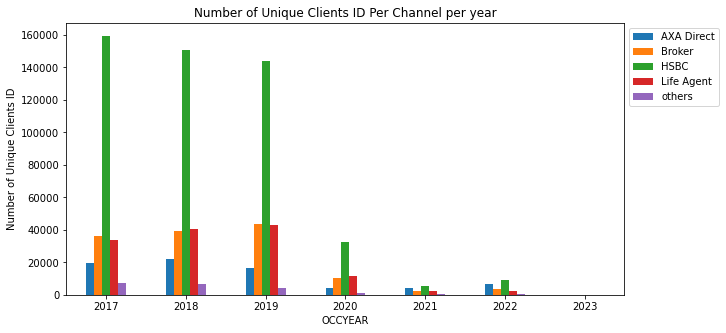

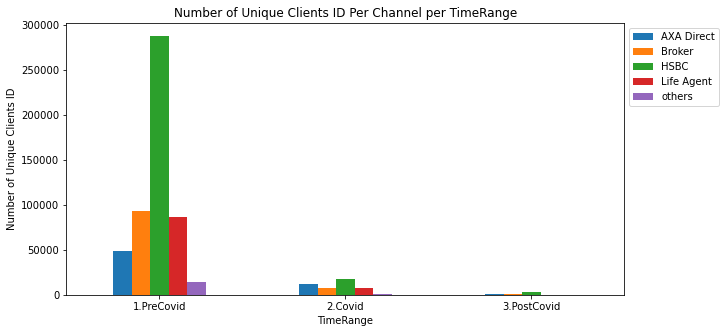

In [78]:
import matplotlib.pyplot as plt
# plot a graph of unique COWNNUM for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique Clients ID
plt.ylabel('Number of Unique Clients ID')
# add title to the graph
plt.title('Number of Unique Clients ID Per Channel per year')
plt.show()

# plot a graph of unique COWNNUM for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['TimeRange','channel'])['modified_SECUITYNO'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique Clients ID
plt.ylabel('Number of Unique Clients ID')
# add title to the graph
plt.title('Number of Unique Clients ID Per Channel per TimeRange')
plt.show()




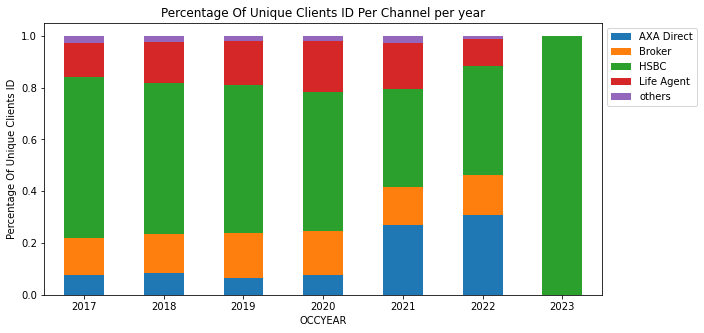

In [79]:
# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique Clients ID
plt.ylabel('Percentage Of Unique Clients ID')
# add title to the graph
plt.title('Percentage Of Unique Clients ID Per Channel per year')
plt.show()



In [80]:
# generate a df of unique COWNNUM for each Channel for each year
df =F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack()
df

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,19476.0,36286.0,159324.0,33683.0,7415.0
2018,22298.0,39063.0,150912.0,40737.0,6487.0
2019,16262.0,43782.0,144086.0,42673.0,4483.0
2020,4483.0,10328.0,32304.0,11765.0,1169.0
2021,3881.0,2090.0,5388.0,2587.0,376.0
2022,6706.0,3276.0,9119.0,2296.0,253.0
2023,NaN,NaN,11.0,NaN,NaN


In [81]:
# AXA vs HSBC vs Others
# have agent vs no agent

## Policy Count


In [82]:
# count number of  unique policies in the column 'contrnb'
F_usefull_PCC['contrnb'].nunique()

1402932

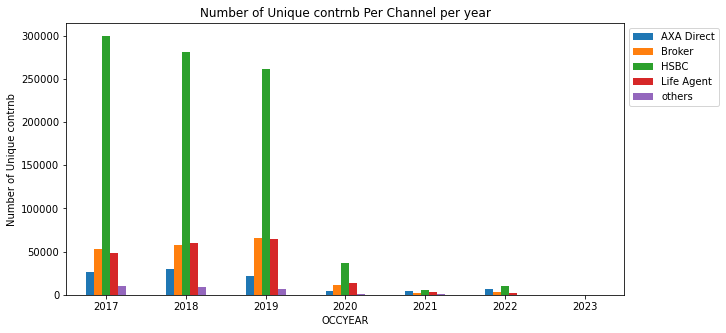

In [83]:
# plot a graph of unique contrnb for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique contrnb
plt.ylabel('Number of Unique contrnb')
# add title to the graph
plt.title('Number of Unique contrnb Per Channel per year')
plt.show()



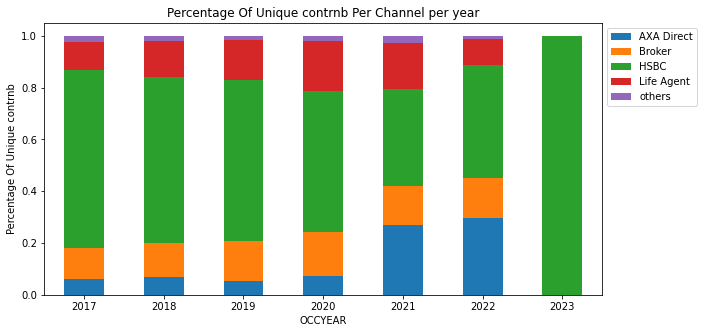

In [84]:
# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique contrnb
plt.ylabel('Percentage Of Unique contrnb')
# add title to the graph
plt.title('Percentage Of Unique contrnb Per Channel per year')
plt.show()



In [85]:
# generate a df of unique contrnb for each Channel for each year
df =F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack()
df

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,26058.0,53338.0,299675.0,48321.0,9967.0
2018,30045.0,57489.0,280591.0,60138.0,9053.0
2019,22291.0,65681.0,261442.0,64279.0,6568.0
2020,4875.0,11609.0,36993.0,13094.0,1302.0
2021,4317.0,2431.0,6026.0,2888.0,412.0
2022,7158.0,3701.0,10499.0,2486.0,256.0
2023,NaN,NaN,11.0,NaN,NaN


In [86]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.0,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid


## Top 5(?) Product by Count/by WGP (weighted sum)

In [87]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.0,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid


In [88]:
# get only useful col and create a new df and drop duplicates
FF_usefull_PCC=F_usefull_PCC[['contrnb','product','OCCDATE','OCCYEAR','channel','Single/Annual','modified_SECUITYNO','gwp']]

In [89]:
# print out shape of the df
print(FF_usefull_PCC.shape)

# drop all duplicate rows
FF_usefull_PCC.drop_duplicates(inplace=True)

# print out shape of the df
print(FF_usefull_PCC.shape)

(2723454, 8)
(2541860, 8)


c:\Users\Nicole.Leung\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [90]:
# find the top 5 product by number of unique policies and carrasponding GWP
FF_usefull_PCC.groupby(['product'])['contrnb'].nunique().sort_values(ascending=False).head(5)




product
TravelSurance (single trip)    541033
SmartTraveller (Single)        420018
Single Trip 2018               310461
SmartTraveller (Annual)         28009
SmartTraveller- Citi            24963
Name: contrnb, dtype: int64

In [91]:
# find the top 5 product by number of unique policies and GWP
FF_usefull_PCC.groupby(['product','contrnb'])['gwp'].mean().sort_values(ascending=False)


product                           contrnb 
SmartTraveller (Single)           Z1261098    925107.000000
Single Trip 2018                  27604951    405530.965000
SmartTraveller (Single)           Z1339244     47256.925000
SmartTraveller Plus (Annual)      Z1577154     41400.000000
Group Biz Travel                  Z1351914     27713.000000
                                                  ...      
Multi Trip 2018                   26685306      -254.766667
                                  25806025      -288.404286
                                  25941145      -288.404286
MultiTrip TravelSurance (Annual)  25019454      -413.982857
SmartTraveller (Annual)           S5410048      -585.000000
Name: gwp, Length: 1402943, dtype: float64

In [92]:
# find the top 5 product by number of unique policies and GWP
FF_usefull_PCC.groupby(['product','contrnb'])['gwp'].sum().sort_values(ascending=False)

product                           contrnb 
SmartTraveller (Single)           Z1261098    925107.00
Single Trip 2018                  27604951    811061.93
Group Biz Travel                  Z1351914    415695.00
SmartTraveller (Annual)           Z0897049    292666.17
Group Biz Travel                  Z0970568    225371.93
                                                ...    
MultiTrip TravelSurance (Annual)  25873504     -1736.50
SmartTraveller (Annual)           S5410048     -1755.00
Multi Trip 2018                   25806025     -2018.83
                                  25941145     -2018.83
MultiTrip TravelSurance (Annual)  25019454     -2897.88
Name: gwp, Length: 1402943, dtype: float64

In [93]:
# show rows where contrnb =Z1261098    and Z0970568
FF_usefull_PCC[FF_usefull_PCC['contrnb'].isin(['Z1261098'])]    

,contrnb,product,OCCDATE,OCCYEAR,channel,Single/Annual,modified_SECUITYNO,gwp
4869774,Z1261098,SmartTraveller (Single),2018-08-20,2018,Broker,NaN,0005952000011096,925107.0


In [94]:
# see how many duplicate rows when contrnb =Z0970568
FF_usefull_PCC[FF_usefull_PCC['contrnb'].isin(['Z0970568'])].duplicated().sum()

0

In [95]:
FF_usefull_PCC[FF_usefull_PCC['contrnb'].isin(['Z0970568'])]

,contrnb,product,OCCDATE,OCCYEAR,channel,Single/Annual,modified_SECUITYNO,gwp
4646626,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,53629.00
4646648,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,24598.00
4646670,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,4573.00
4646692,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,5000.00
4646714,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,0.00
4646824,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,699.45
4646890,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,2268.49
4646956,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,-781.37
4647088,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,144.93
4647154,Z0970568,Group Biz Travel,2017-04-01,2017,Broker,Annual,1199149000006169,60529.00


In [96]:
# for each contrnb, find the number of row where gwp=<0 by np.where or np.select, and sort
FF_usefull_PCC.groupby(['contrnb'])['gwp'].apply(lambda x: np.where(x<=0,1,0).sum()).sort_values(ascending=False).head(20)

contrnb
25400247    20
27562394    19
25788587    17
25400700    13
26174506    12
Z0897049    11
26684697     9
25860040     9
24937728     8
25192739     7
27648755     7
25714356     7
25362672     7
24923877     7
25677272     7
Z1473424     7
25841938     7
25970573     7
25289629     7
25355608     7
Name: gwp, dtype: int32

In [97]:
# for each contrnb, find the % of row where gwp=<0 by np.where or np.select, sort, plot

In [98]:
FF_usefull_PCC[FF_usefull_PCC['contrnb'].isin(['25400247'])]

,contrnb,product,OCCDATE,OCCYEAR,channel,Single/Annual,modified_SECUITYNO,gwp
2104635,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,20505.33
2104638,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,19296.82
2104641,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-46.60
2104644,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-264.07
2104647,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,368.81
2104650,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,389.94
2104653,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-98.56
2104656,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-558.50
2104659,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-35.60
2104662,25400247,BUSINESS TRAVELCARE,2017-04-01,2017,HSBC,NaN,C176170,-201.73


## Premium (GWP)

## Sum Insured

## Claim Amt/Rate

In [99]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid"
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.0,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid


In [100]:
# get unique paymnt_n and paymnt_g
F_usefull_PCC.groupby(['paymnt_g'])['contrnb'].nunique().sort_values(ascending=False)

paymnt_g
0.00          13622
500.00         3097
2000.00        3093
3000.00        3039
1000.00        2293
              ...  
1487.88           1
1487.85           1
1487.78           1
1487.45           1
2374679.69        1
Name: contrnb, Length: 27648, dtype: int64

In [101]:
# conver all paymnt_n and paymnt_g with value 0 to NaN
F_usefull_PCC['paymnt_n']=F_usefull_PCC['paymnt_n'].replace(0,np.nan)
F_usefull_PCC['paymnt_g']=F_usefull_PCC['paymnt_g'].replace(0,np.nan)

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2479237356.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['paymnt_n']=F_usefull_PCC['paymnt_n'].replace(0,np.nan)
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2479237356.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['paymnt_g']=F_usefull_PCC['paymnt_g'].replace(0,np.nan)


In [102]:
# create a new column 'REP_Year' in F_usefull_PCC using column DATREP
F_usefull_PCC['REP_Year'] = F_usefull_PCC['DATREP'].dt.year

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2084402355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['REP_Year'] = F_usefull_PCC['DATREP'].dt.year


In [103]:
# create a new col 'CCY' in F_usefull_PCC using column 'CCDATE'
# F_usefull_PCC['CCY'] = F_usefull_PCC['CCDATE_x'].dt.year

In [104]:
# generate a flag column named claim_flag, if CLAIM is not NaN, then there is a claim, if CLAIM is NaN, then there is no claim, for each contrnb, find if there is a claim or not
F_usefull_PCC['claim_flag']=np.where(F_usefull_PCC['CLAIM'].isnull(),0,1)



C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/3585193776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['claim_flag']=np.where(F_usefull_PCC['CLAIM'].isnull(),0,1)


In [105]:
# generate a flag colume named CCY_claim_flag, if CCY is the same as REP_Year, then there is a claim at this year , if CCY is not the same as REP_Year, then there is no claim, for each contrnb, find if there is a claim or not for each year
F_usefull_PCC['CCY_claim_flag']=np.where(F_usefull_PCC['CCYEAR']==F_usefull_PCC['REP_Year'],1,0)


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/434510091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['CCY_claim_flag']=np.where(F_usefull_PCC['CCYEAR']==F_usefull_PCC['REP_Year'],1,0)


In [106]:
# sort by claim_flag by decending order then keep first for each contrnb
FF_usefull_PCC=F_usefull_PCC.sort_values(by=['claim_flag'],ascending=False).drop_duplicates(subset=['contrnb'],keep='first')

In [107]:
FF_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
2124022,2665159,25409875,2018-05-14,2018-05-14,HSBC,TravelSurance (single trip),Single,Area 2,Friend or Relative,0.0,8. 31-60 Days,62.0,6. Age 61 - 70,325.13,NB,F,E662606,Y0521647,2018-05-14,2018-07-19,9000.0,9000.0,NaN,2018,2018,2018-05-14,1.PreCovid,"1,PreCovid",2018.0,1,1
4592258,0054215,Z0897001,2017-04-01,2019-07-01,Broker,Group Biz Travel,Annual,NA,NA,NaN,Annual,9999.0,9. unknown,497.54,RN,NaN,413673F,9T02QDJA,2019-07-01,2019-12-02,NaN,NaN,Annual,2017,2019,2017-04-01,1.PreCovid,"1,PreCovid",2019.0,1,1
2767161,2869163,25727708,2019-05-29,2019-05-29,HSBC,Single Trip 2018,Single,Asia,Standard,6.0,4. 6-7 Days,27.0,2. Age 17 - 30,26.67,NB,M,V136617,9T01Z5OA,2019-05-29,2019-06-14,3722.0,3722.0,NaN,2019,2019,2019-05-29,1.PreCovid,"1,PreCovid",2019.0,1,1
2478154,2656302,25586690,2018-11-29,2018-11-29,HSBC,TravelSurance (single trip),Single,Area 1,Self Only,0.0,3. 4-5 Days,29.0,2. Age 17 - 30,69.02,NB,F,Y037662,8T019ZNA,2018-11-29,2018-12-10,2000.0,2000.0,NaN,2018,2018,2018-11-29,1.PreCovid,"1,PreCovid",2018.0,1,1
1591543,2518191,25093161,2017-08-16,2017-08-16,HSBC,TravelSurance (single trip),Single,Area 1,Self Only,0.0,5. 8-10 Days,23.0,2. Age 17 - 30,292.40,NB,F,Y309573,Y0481284,2017-08-16,2017-09-01,400.0,400.0,NaN,2017,2017,2017-08-16,1.PreCovid,"1,PreCovid",2017.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2156492,2675195,25424436,2018-05-30,2018-05-30,HSBC,TravelSurance (single trip),Single,Area 2,Self Only,12.0,6. 11-14 Days,52.0,5. Age 51 - 60,56.84,NB,M,D499627,NaN,NaT,NaT,NaN,NaN,NaN,2018,2018,2018-05-30,1.PreCovid,"1,PreCovid",NaN,0,0
2156477,2675189,25424428,2018-06-07,2019-06-07,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 1,Self & Spouse,0.0,Annual,54.0,5. Age 51 - 60,0.00,RN,M,G547792,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-06-07,1.PreCovid,"1,PreCovid",NaN,0,0
2156460,2646850,25424426,2018-06-02,2018-06-02,HSBC,TravelSurance (single trip),Single,Area 1,Self Only,8.0,5. 8-10 Days,77.0,7. Age 71 - 80,29.03,NB,F,A210811,NaN,NaT,NaT,NaN,NaN,NaN,2018,2018,2018-06-02,1.PreCovid,"1,PreCovid",NaN,0,0
2156462,2675188,25424427,2018-06-20,2018-06-20,HSBC,TravelSurance (single trip),Single,Area 1,Self Only,6.0,4. 6-7 Days,70.0,6. Age 61 - 70,23.36,NB,F,A761235,NaN,NaT,NaT,NaN,NaN,NaN,2018,2018,2018-06-20,1.PreCovid,"1,PreCovid",NaN,0,0


In [108]:
# number of unique contrnb in FF_usefull_PCC
FF_usefull_PCC['contrnb'].nunique()

1402932

In [109]:
# calculate the claim rate for each channel, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb))
FF_usefull_PCC.groupby(['channel'])['claim_flag'].mean().sort_values(ascending=False)

channel
others        0.095765
AXA Direct    0.084429
Life Agent    0.082067
Broker        0.068464
HSBC          0.044961
Name: claim_flag, dtype: float64

<AxesSubplot:title={'center':'Claim Rate Per Channel'}, xlabel='channel'>

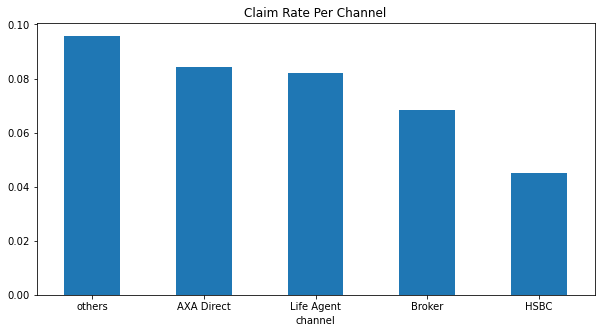

In [110]:
# calculate the claim rate for each channel, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
# add title to the graph
plt.title('Claim Rate Per Channel')
FF_usefull_PCC.groupby(['channel'])['claim_flag'].mean().sort_values(ascending=False).plot(kind='bar',stacked=False,figsize=(10,5),rot=0)

In [111]:
#modify by ccyear
# CCYEAR 2017 
# CCYEAR 2018 

Text(0.5, 1.0, 'Claim Rate by Channel and OCCYEAR')

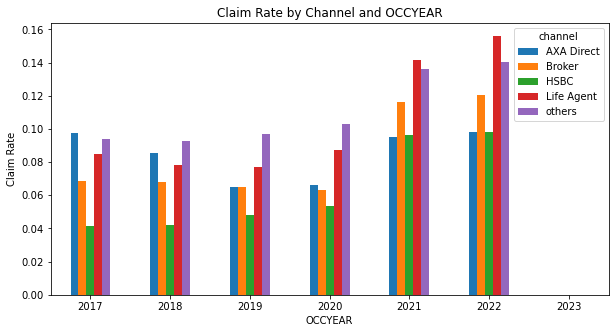

In [112]:
# calculate the claim rate each year for each channel, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FF_usefull_PCC.groupby(['OCCYEAR','channel'])['claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label
plt.ylabel('Claim Rate')
# add title
plt.title('Claim Rate by Channel and OCCYEAR')

In [113]:
# get non duplicate contrnb by 2 colume CCY and CCY_claim_flag and return to a new df
FFF_usefull_PCC=F_usefull_PCC.copy()

FFF_usefull_PCC=FFF_usefull_PCC.drop_duplicates(subset=['contrnb','CCYEAR','CCY_claim_flag'],keep='first')

Text(0.5, 1.0, 'Claim Rate at each Time Range by CCDATE')

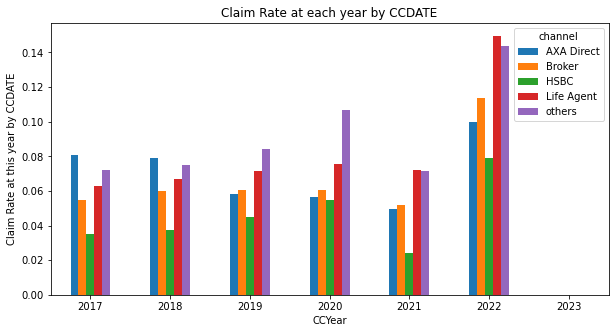

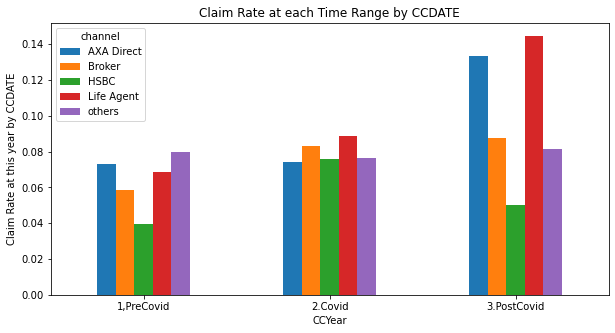

In [114]:
# calculate the claim rate each year for each channel, using CCY_claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FFF_usefull_PCC.groupby(['CCYEAR','channel'])['CCY_claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label
plt.ylabel('Claim Rate at this year by CCDATE')
# add X axis label
plt.xlabel('CCYear')
# add title
plt.title('Claim Rate at each year by CCDATE')


# calculate the claim rate each year for each channel, using CCY_claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FFF_usefull_PCC.groupby(['CCTimeRange','channel'])['CCY_claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label
plt.ylabel('Claim Rate at this year by CCDATE')
# add X axis label
plt.xlabel('CCYear')
# add title
plt.title('Claim Rate at each Time Range by CCDATE')

Text(0.5, 1.0, 'Claim Rate by Plan1 and Channel')

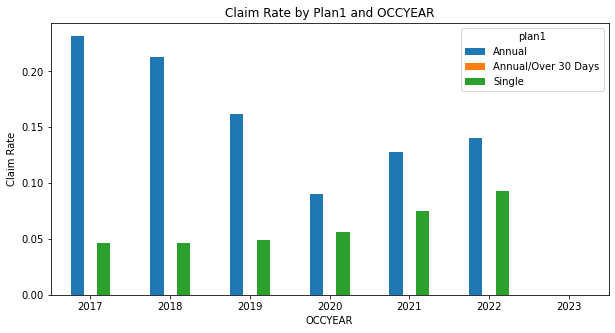

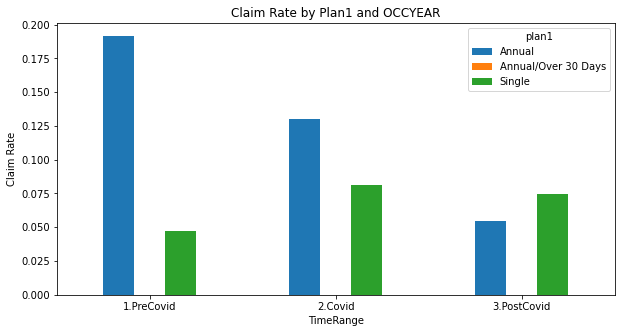

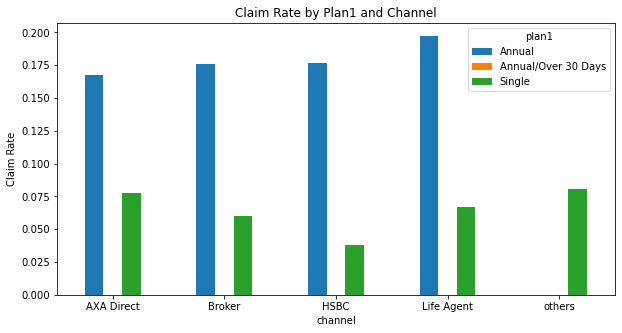

In [115]:
# calculate the claim rate each year for each plan1, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FF_usefull_PCC.groupby(['OCCYEAR','plan1'])['claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# add title
plt.title('Claim Rate by Plan1 and OCCYEAR')


# calculate the claim rate each year for each plan1, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FF_usefull_PCC.groupby(['TimeRange','plan1'])['claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# add title
plt.title('Claim Rate by Plan1 and OCCYEAR')


# calculate the claim rate each channel for each plan1, using claim_flag
FF_usefull_PCC.groupby(['channel','plan1'])['claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# add title
plt.title('Claim Rate by Plan1 and Channel')

Text(0.5, 1.0, 'Claim Rate at each channel by CCDATE per Plan Type')

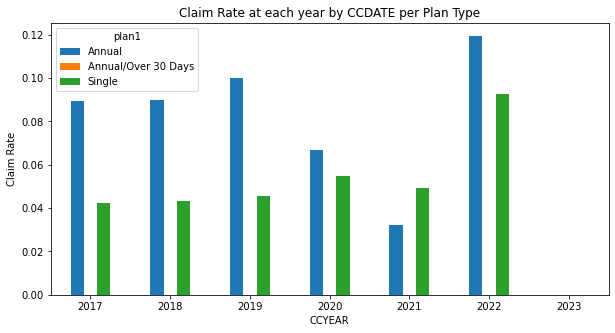

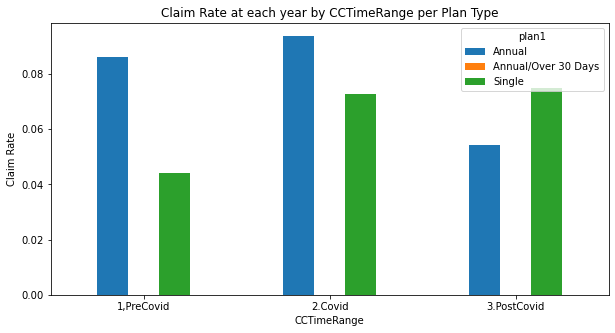

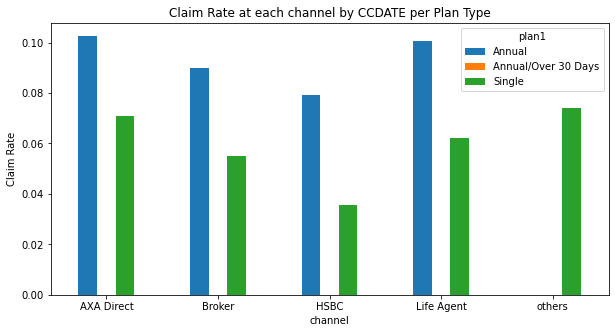

In [116]:
# calculate the claim rate each year for each plan1, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FF_usefull_PCC.groupby(['CCYEAR','plan1'])['CCY_claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# Add title
plt.title('Claim Rate at each year by CCDATE per Plan Type')


# calculate the claim rate each year for each plan1, using claim_flag,claim rate= (number of contrnb where claim_flag=1)/(number of contrnb)),then plot graph
FF_usefull_PCC.groupby(['CCTimeRange','plan1'])['CCY_claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# Add title
plt.title('Claim Rate at each year by CCTimeRange per Plan Type')


# calculate the claim rate each channel for each plan1, using claim_flag
FF_usefull_PCC.groupby(['channel','plan1'])['CCY_claim_flag'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# add Y axis label 
plt.ylabel('Claim Rate')
# Add title
plt.title('Claim Rate at each channel by CCDATE per Plan Type')

In [117]:
# drop duplicate by contrnb CLAIM DATREP and return to a new df named F_paymnt
F_paymnt=F_usefull_PCC.drop_duplicates(subset=['contrnb','CLAIM','DATREP','paymnt_n','paymnt_g'],keep='first')

In [118]:
F_paymnt

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.80,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
559579,2652403,24594510,2018-04-16,2018-04-16,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,42.0,4. Age 41 - 50,29.30,NB,F,K460112,NaN,NaT,NaT,NaN,NaN,NaN,2018,2018,2018-04-16,1.PreCovid,"1,PreCovid",NaN,0,0
1046324,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,18.0,7. 15-30 Days,69.0,6. Age 61 - 70,127.95,NB,M,E068903,NaN,NaT,NaT,NaN,NaN,NaN,2017,2017,2017-01-02,1.PreCovid,"1,PreCovid",NaN,0,0
1056514,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,36.0,3. Age 31 - 40,32.55,NB,M,Z059410,Y0453283,2017-01-06,2017-03-29,NaN,NaN,NaN,2017,2017,2017-01-06,1.PreCovid,"1,PreCovid",2017.0,1,1
1060630,2079048,24837090,2017-01-08,2017-01-08,HSBC,TravelSurance (single trip),Single,Area 2,Self Only,9.0,5. 8-10 Days,45.0,4. Age 41 - 50,46.65,NB,M,G475149,NaN,NaT,NaT,NaN,NaN,NaN,2017,2017,2017-01-08,1.PreCovid,"1,PreCovid",NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.00,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid,NaN,0,0
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.00,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.00,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid,NaN,0,0
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.00,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0


In [119]:
# count how many paymnt_g is 0
F_paymnt[F_paymnt['paymnt_g']==0].shape

(0, 31)

Text(0.5, 1.0, 'Total paymnt_g Per CCTimeRange')

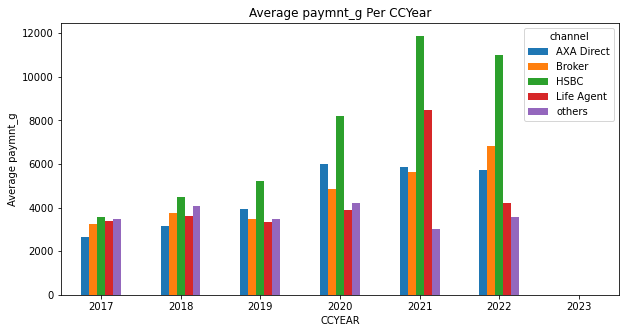

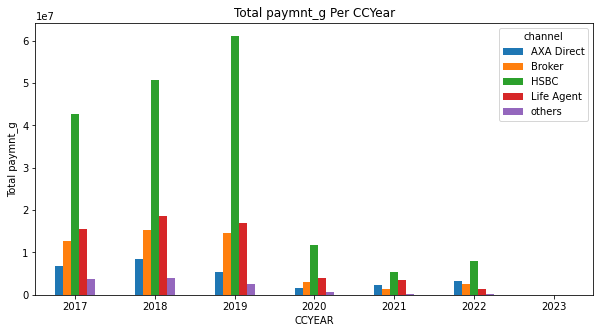

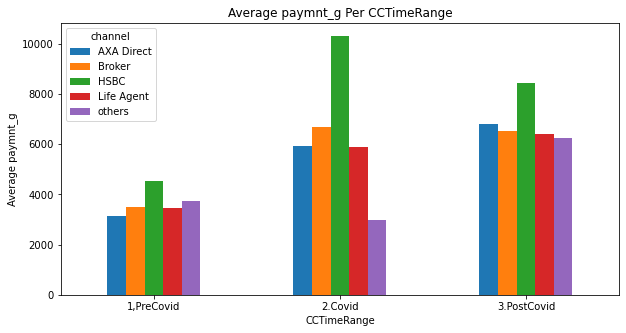

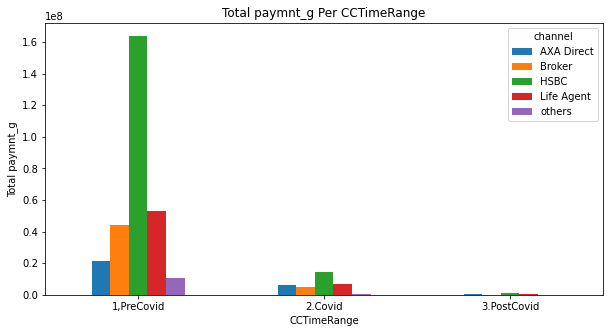

In [120]:
###########filter by plan1 first
# calculate the average paymnt_g for each channel for each year then plot graph
F_paymnt.groupby(['CCYEAR','channel'])['paymnt_g'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Average paymnt_g')
# add title to the graph
plt.title('Average paymnt_g Per CCYear')
# calculate the total paymnt_g for each channel for each year then plot graph
F_paymnt.groupby(['CCYEAR','channel'])['paymnt_g'].sum().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Total paymnt_g')
# add title to the graph
plt.title('Total paymnt_g Per CCYear')
# # calculate the average paymnt_n for each channel for each year then plot graph, add Y axis Label
# F_paymnt.groupby(['OCCYEAR','channel'])['paymnt_n'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# plt.ylabel('Average paymnt_n')
# # calculate the total paymnt_n for each channel for each year then plot graph, add Y axis Label
# F_paymnt.groupby(['OCCYEAR','channel'])['paymnt_n'].sum().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# plt.ylabel('Total paymnt_n')





# calculate the average paymnt_g for each channel for each year then plot graph
F_paymnt.groupby(['CCTimeRange','channel'])['paymnt_g'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Average paymnt_g')
# add title to the graph
plt.title('Average paymnt_g Per CCTimeRange')
# calculate the total paymnt_g for each channel for each year then plot graph
F_paymnt.groupby(['CCTimeRange','channel'])['paymnt_g'].sum().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Total paymnt_g')
# add title to the graph
plt.title('Total paymnt_g Per CCTimeRange')


In [121]:
# see how many rows have different paymnt_g and paymnt_n
F_paymnt[F_paymnt['paymnt_g']!=F_paymnt['paymnt_n']].shape

(1337148, 31)

Text(0.5, 1.0, 'Total paymnt_g Per PlanType and Channel')

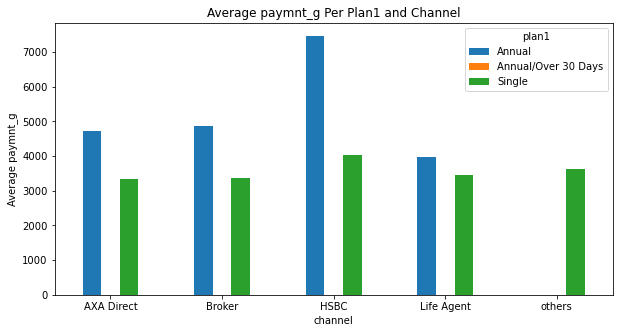

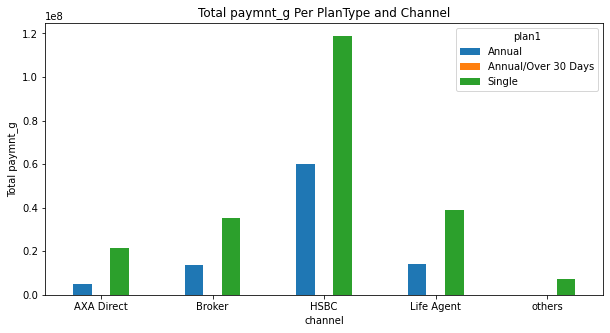

In [122]:
# calculate the average paymnt_g for each plan1 for each channel then plot graph
# check 
F_paymnt.groupby(['channel','plan1'])['paymnt_g'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Average paymnt_g')
# add title to the graph
plt.title('Average paymnt_g Per Plan1 and Channel')

# calculate the total paymnt_g for each plan1 for each channel then plot graph
F_paymnt.groupby(['channel','plan1'])['paymnt_g'].sum().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.ylabel('Total paymnt_g')
# add title to the graph
plt.title('Total paymnt_g Per PlanType and Channel')
# # calculate the average paymnt_n for each plan1 for each channel then plot graph, add Y axis Label
# F_paymnt.groupby(['channel','plan1'])['paymnt_n'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# plt.ylabel('Average paymnt_n')
# # calculate the total paymnt_n for each plan1 for each channel then plot graph, add Y axis Label
# F_paymnt.groupby(['channel','plan1'])['paymnt_n'].sum().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# plt.ylabel('Total paymnt_n')





## New Business Count/Rate

## Travel Duration

Text(0.5, 1.0, 'Average duration for plan1=Annual Per OCCYEAR and Channel')

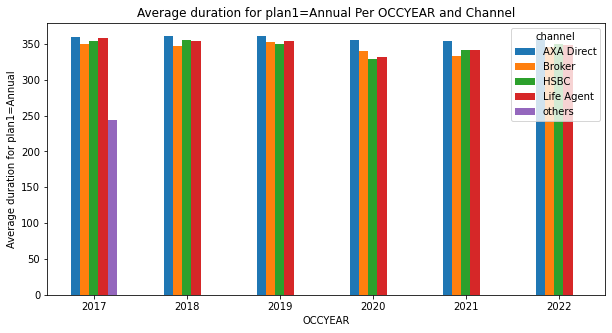

In [123]:
# for plan1=Annual, calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_paymnt[F_paymnt['plan1']=='Annual'].groupby(['OCCYEAR','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
# y axis label 
plt.ylabel('Average duration for plan1=Annual')
# add title to the graph
plt.title('Average duration for plan1=Annual Per OCCYEAR and Channel')

In [124]:
F_usefull_PCC['plan1'].unique()

['Annual', 'Single', NaN]
Categories (3, object): ['Annual', 'Annual/Over 30 Days', 'Single']

Text(0.5, 1.0, 'Average duration for plan1=Single Per OCCYEAR and Channel')

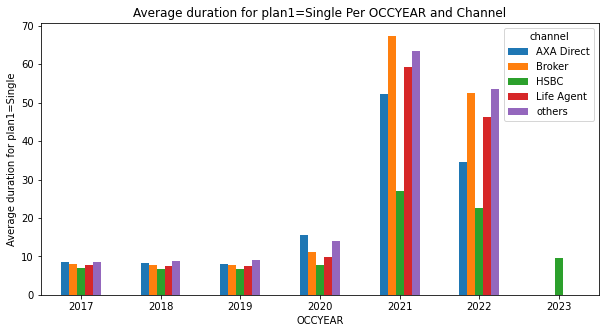

In [125]:
# for plan1=Single , calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_paymnt[F_paymnt['plan1']=='Single'].groupby(['OCCYEAR','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Average duration for plan1=Single')
# add title to the graph
plt.title('Average duration for plan1=Single Per OCCYEAR and Channel')


## Travel Frequency

## Inforce/Lapsed Count/Ratio of Annual Plan

## Age Range

In [126]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid,NaN,0,0
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.0,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid,NaN,0,0
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0


In [127]:
# sample=F_usefull_PCC[['modified_SECUITYNO','age','OCCDATE','contrnb']]
sample =F_usefull_PCC

In [128]:
F_usefull_PCC[F_usefull_PCC['modified_SECUITYNO']=='C75700360']

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113550,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,1608.2,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113551,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,23.0,2. Age 17 - 30,-583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113552,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,-1608.2,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0


In [129]:
sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()][sample['modified_SECUITYNO']=='C75700360']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_2260/2318935542.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()][sample['modified_SECUITYNO']=='C75700360']


,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0


In [130]:
uniqueAgeForEachCustomerAndEachPolicyNo=sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()]

<AxesSubplot:>

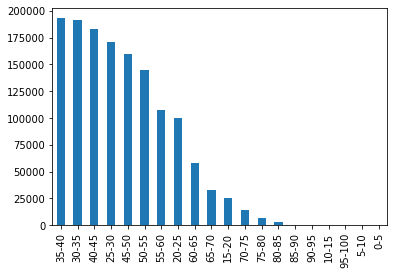

In [131]:
#drop the rows where age is 9999 or 100 or 0 or 1 
uniqueAgeForEachCustomerAndEachPolicyNo=uniqueAgeForEachCustomerAndEachPolicyNo[~uniqueAgeForEachCustomerAndEachPolicyNo['age'].isin([9999,100,0,1])]
#divide the age into different age group, for example age at 46 belongs to the age group 46-50, age at 42 belongs to the age group 40-45, value count of each age group then plot graph to show the distribution of age group using seaborn
uniqueAgeForEachCustomerAndEachPolicyNo['age_GAP']=pd.cut(uniqueAgeForEachCustomerAndEachPolicyNo['age'],bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100],labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100'])
uniqueAgeForEachCustomerAndEachPolicyNo['age_GAP'].value_counts().plot(kind="bar")


In [132]:
uniqueAgeForEachCustomerAndEachPolicyNo

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag,age_GAP
4886434,0362895,Z1314626,2019-11-19,2019-11-19,Broker,SmartTraveller (Single),Single,VIP,Insured Only,5.0,3. 4-5 Days,66.0,6. Age 61 - 70,225.00,NB,F,0362895,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-11-19,1.PreCovid,"1,PreCovid",NaN,0,0,65-70
4886372,0548621,Z1314273,2019-10-17,2019-10-17,Broker,SmartTraveller (Single),Single,Classic,Insured Only,0.0,1. 0 Days,42.0,4. Age 41 - 50,201.00,NB,F,0548621,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-10-17,1.PreCovid,"1,PreCovid",NaN,0,0,40-45
2103609,2658910,25399038,2018-05-02,2018-05-02,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Spouse,365.0,Annual,50.0,4. Age 41 - 50,472.20,NB,M,055433456,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-05-02,1.PreCovid,"1,PreCovid",NaN,0,0,45-50
1413886,2465912,25006911,2017-04-28,2017-04-28,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,12.0,6. 11-14 Days,51.0,5. Age 51 - 60,95.88,NB,F,099230421,NaN,NaT,NaT,NaN,NaN,NaN,2017,2017,2017-04-28,1.PreCovid,"1,PreCovid",NaN,0,0,50-55
1741175,2465912,25191526,2018-01-12,2018-01-12,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self & Spouse,0.0,Annual,52.0,5. Age 51 - 60,1072.20,NB,F,099230421,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-01-12,1.PreCovid,"1,PreCovid",NaN,0,0,50-55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632205,2236132,25666632,2019-03-08,2019-03-08,HSBC,Single Trip 2018,Single,Worldwide,Standard,4.0,3. 4-5 Days,30.0,2. Age 17 - 30,42.08,NB,M,Z992010,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-03-08,1.PreCovid,"1,PreCovid",NaN,0,0,25-30
2684435,2236132,25689706,2019-04-09,2019-04-09,HSBC,Single Trip 2018,Single,Asia,Standard,6.0,4. 6-7 Days,30.0,2. Age 17 - 30,31.49,NB,M,Z992010,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-04-09,1.PreCovid,"1,PreCovid",NaN,0,0,25-30
2790665,2236132,25738259,2019-06-05,2019-06-05,HSBC,Single Trip 2018,Single,Asia,Standard,6.0,4. 6-7 Days,30.0,2. Age 17 - 30,32.39,NB,M,Z992010,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-06-05,1.PreCovid,"1,PreCovid",NaN,0,0,25-30
4192081,1406808,S5377814,2019-04-01,2019-04-01,others,SmartTraveller- Citi,Single,Classic,Insured Only,2.0,2. 1-3 Days,30.0,2. Age 17 - 30,142.80,NB,F,Z992011,NaN,NaT,NaT,NaN,NaN,NaN,2019,2019,2019-04-01,1.PreCovid,"1,PreCovid",NaN,0,0,25-30


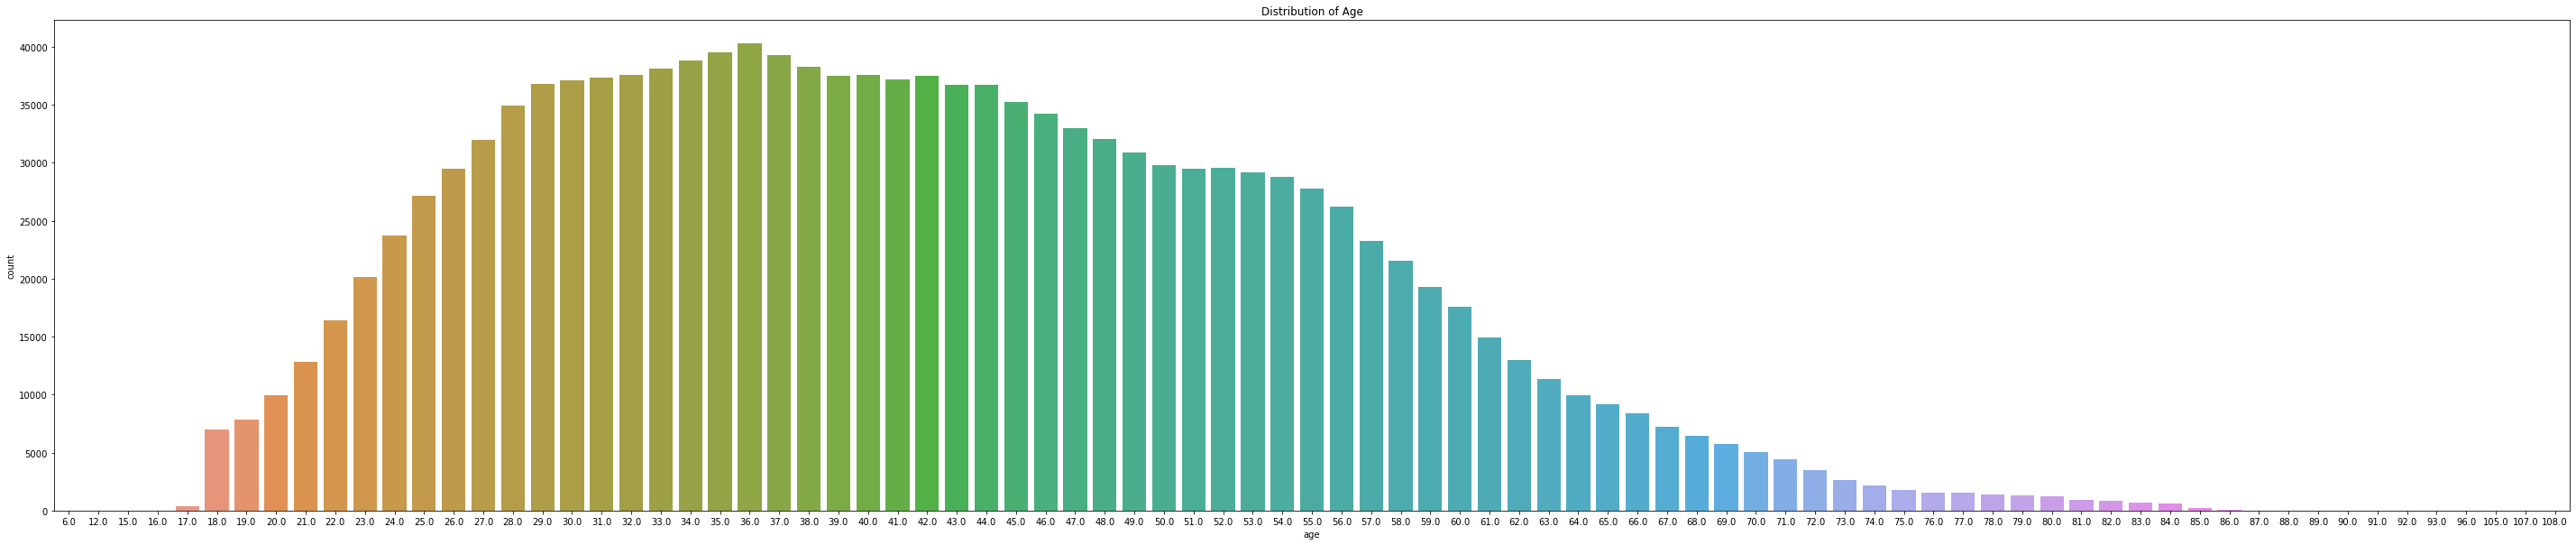

In [134]:
# plot graph using seaborn to show the value count of age_gp 
import seaborn as sns
plt.figure(figsize=(50,10))
df=uniqueAgeForEachCustomerAndEachPolicyNo
sns.countplot(x='age',data =df)
plt.title('Distribution of Age')
# add title
plt.title('Distribution of Age')
plt.show()

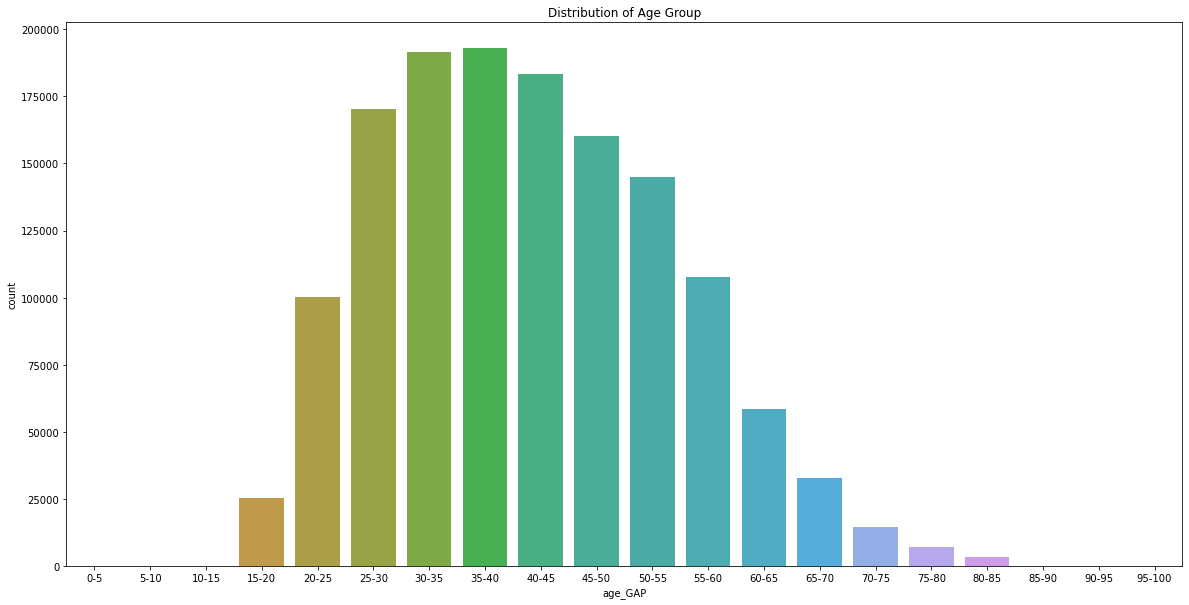

In [135]:
# plot graph using seaborn to show the value count of age_gp 
plt.figure(figsize=(20,10))
df=uniqueAgeForEachCustomerAndEachPolicyNo
sns.countplot(x='age_GAP',data =df)
plt.title('Distribution of Age Group')
plt.show()


In [136]:
# get the value count of each age group for each channel for each year then generate a pivot table
uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel','age_GAP'])['age_GAP'].count().unstack().fillna(0)

age_GAP             0-5  5-10  10-15  15-20  20-25  25-30  30-35  35-40  \
OCCYEAR channel                                                           
2017    AXA Direct    0     1      0    880   3815   5437   4612   3466   
        Broker        0     0      1   1658   4568   5594   6092   6568   
        HSBC          0     0      4   2806  17133  38154  46902  45348   
        Life Agent    0     0      0   2061   5393   5754   5397   4986   
        others        0     0      0    252    865   1740   1704   1441   
2018    AXA Direct    0     0      0    952   4461   6249   4976   3879   
        Broker        0     0      0   1619   4476   5840   6346   7026   
        HSBC          0     0      0   2346  15383  33849  41672  42795   
        Life Agent    0     0      0   2500   6553   7005   6400   6402   
        others        0     0      0    185    705   1433   1531   1335   
2019    AXA Direct    0     0      0    659   2728   4258   3449   2977   
        Broker        0     0      0   2132   5050   6428   6962   7886   
        HSBC          0     0      0   2195  14719  29835  35528  38307   
        Life Agent    0     0      0   2649   6901   7349   6862   6953   
        others        0     0      0    111    481    940   1010    926   
2020    AXA Direct    0     0      0    123    486    814    792    692   
        Broker        0     0      0    337    866   1121   1306   1466   
        HSBC          0     0      0    380   2071   3988   4958   5263   
        Life Agent    0     0      0    442   1286   1539   1457   1422   
        others        0     0      0     26     75    137    151    143   
2021    AXA Direct    0     0      0     96    304    376    388    365   
        Broker        0     0      0     72    103    116    123    138   
        HSBC          0     0      0    127    201    363    422    537   
        Life Agent    0     0      0     81    134     99    108    127   
        others        0     0      0     19     18      8     10     17   
2022    AXA Direct    0     0      0    229    789    892    901    851   
        Broker        0     0      0     76    193    206    246    368   
        HSBC          0     0      0    103    381    728    964   1100   
        Life Agent    0     0      0     58    221    174    182    183   
        others        0     0      0      5     13     13     22     17   
2023    AXA Direct    0     0      0      0      0      0      0      0   
        Broker        0     0      0      0      0      0      0      0   
        HSBC          0     0      0      0      0      1      1      1   
        Life Agent    0     0      0      0      0      0      0      0   
        others        0     0      0      0      0      0      0      0   

age_GAP             40-45  45-50  50-55  55-60  60-65  65-70  70-75  75-80  \
OCCYEAR channel                                                              
2017    AXA Direct   2561   1760   1282    870    511    342    161    101   
        Broker       6768   6471   5743   3835   2372   1545    677    400   
        HSBC        41905  34490  31653  21529  10611   5455   1947   1122   
        Life Agent   5381   5150   5230   3698   2390   1292    569    363   
        others       1156    822    667    392    246    133     47     28   
2018    AXA Direct   2995   2156   1514   1083    714    475    224    131   
        Broker       7467   6887   6321   4558   2854   1977    964    459   
        HSBC        39998  33186  29231  21637  10745   5762   2255   1071   
        Life Agent   6383   6266   6473   4977   3096   1875    906    598   
        others       1060    890    673    382    197    150     61     14   
2019    AXA Direct   2428   1903   1345    979    592    427    207    100   
        Broker       7994   7884   7380   5665   3529   2367   1173    523   
        HSBC        36954  32179  28052  22221  11323   5948   2642    953   
        Life Agent   6796   6589   6689   5708   3448 

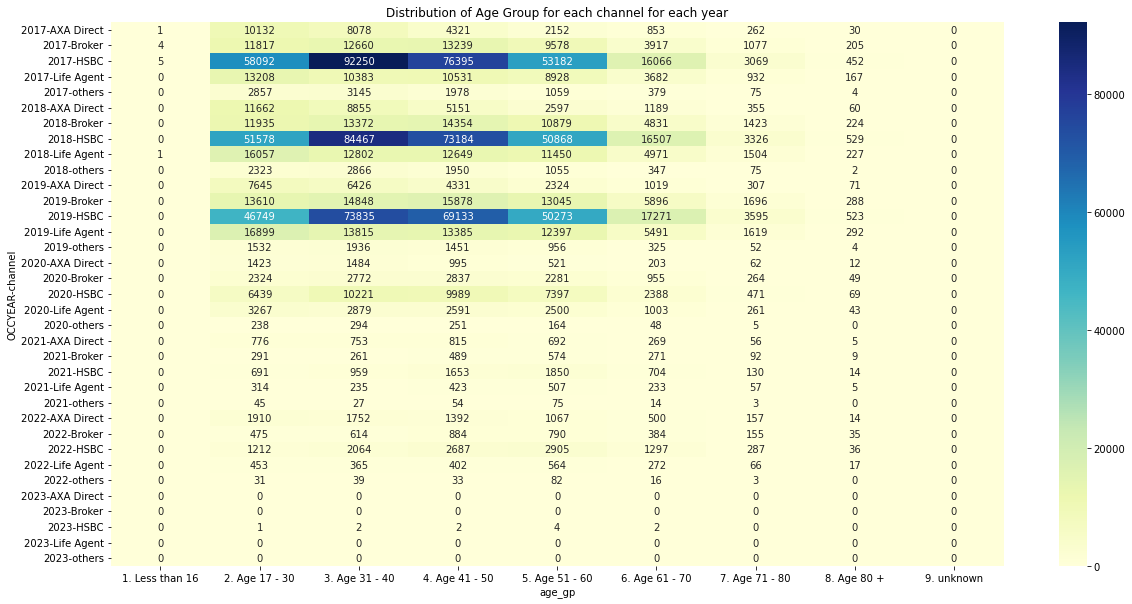

In [137]:
# get the value count of each age group for each channel for each year then generate a heat map
plt.figure(figsize=(20,10))
sns.heatmap(uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel','age_gp'])['age_gp'].count().unstack().fillna(0),annot=True,fmt='d',cmap='YlGnBu')
plt.title('Distribution of Age Group for each channel for each year')
plt.show()


In [138]:
#find the age_gp(and the number) with the most number for each channel for each year then generate a table

uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age_GAP'].agg(lambda x:x.value_counts().index[0]).sort_values(ascending=False).unstack()

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,25-30,40-45,30-35,25-30,25-30
2018,25-30,40-45,35-40,25-30,30-35
2019,25-30,40-45,35-40,25-30,30-35
2020,25-30,35-40,35-40,25-30,30-35
2021,45-50,50-55,50-55,50-55,50-55
2022,30-35,45-50,45-50,50-55,50-55
2023,NaN,NaN,55-60,NaN,NaN


In [139]:
#find the age_gp(and the number) with the most number for each channel for each year then generate a table

uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age_gp'].agg(lambda x:x.value_counts().index[0]).sort_values(ascending=False).unstack()

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,3. Age 31 - 40
2018,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,3. Age 31 - 40
2019,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,3. Age 31 - 40
2020,3. Age 31 - 40,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,3. Age 31 - 40
2021,4. Age 41 - 50,5. Age 51 - 60,5. Age 51 - 60,5. Age 51 - 60,5. Age 51 - 60
2022,2. Age 17 - 30,4. Age 41 - 50,5. Age 51 - 60,5. Age 51 - 60,5. Age 51 - 60
2023,NaN,NaN,5. Age 51 - 60,NaN,NaN


<AxesSubplot:xlabel='OCCYEAR'>

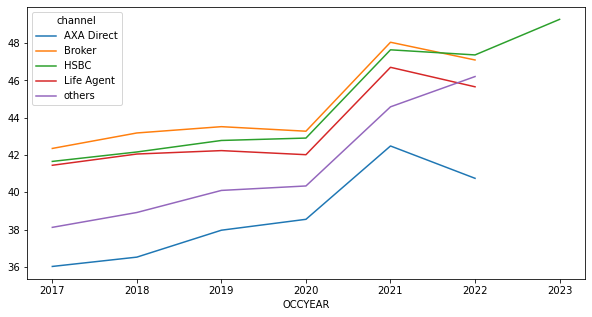

In [140]:
# calculate average age for each channel for each year then plot line graph
uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age'].mean().sort_values(ascending=False).unstack().plot(kind='line',figsize=(10,5),rot=0)



Text(0, 0.5, 'Average age')

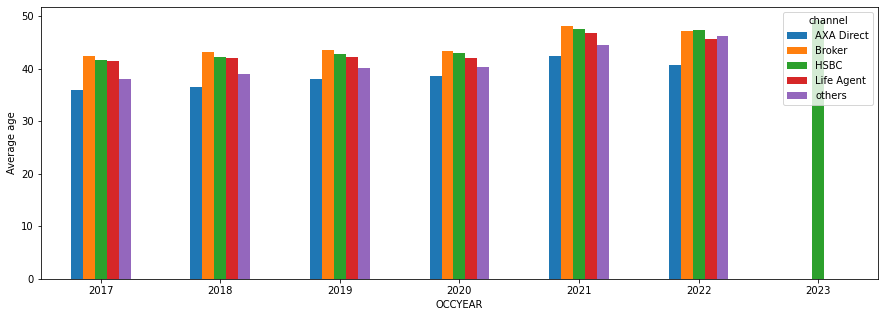

In [141]:
uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(15,5),rot=0)
plt.ylabel('Average age')

Text(0.5, 1.0, 'Average age for each channel for each year')

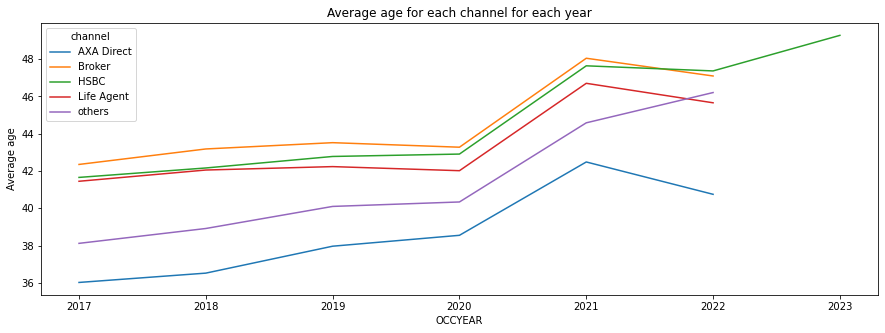

In [144]:
uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age'].mean().sort_values(ascending=False).unstack().plot(kind='line',stacked=False,figsize=(15,5),rot=0)
plt.ylabel('Average age')
# add title
plt.title('Average age for each channel for each year')

## Gender

In [142]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE_x,channel,product,plan1,plan2,plan3,duration,duration_grp,age,age_gp,gwp,nbrn,CLTSEX,modified_SECUITYNO,CLAIM,CCDATE_y,DATREP,paymnt_n,paymnt_g,Single/Annual,OCCYEAR,CCYEAR,CCDATE,TimeRange,CCTimeRange,REP_Year,claim_flag,CCY_claim_flag
113545,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,22.0,2. Age 17 - 30,583.8,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113546,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,1608.2,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113547,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113548,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,22.0,2. Age 17 - 30,0.0,NB,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2018,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
113549,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,23.0,2. Age 17 - 30,583.8,RN,M,C75700360,NaN,NaT,NaT,NaN,NaN,Annual,2018,2019,2018-04-10,1.PreCovid,"1,PreCovid",NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946431,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9999.0,9. unknown,410.0,NB,NaN,1434619,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-26,3.PostCovid,3.PostCovid,NaN,0,0
4946432,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,69.0,6. Age 61 - 70,394.0,NB,M,E478085,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0
4946433,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,62.0,6. Age 61 - 70,196.0,NB,NaN,D241066,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-11-04,3.PostCovid,3.PostCovid,NaN,0,0
4946434,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,43.0,4. Age 41 - 50,394.0,NB,M,K957229,NaN,NaT,NaT,NaN,NaN,NaN,2022,2022,2022-10-25,3.PostCovid,3.PostCovid,NaN,0,0
